# Supervised vs SimCLR vs SupCon vs Byol
### OOD Robustness 

Compare which method best separates in-distribution (ID) from out-of-distribution (OOD) data.

**Dataset structure:**
```
dataset_ood/
  train/          — CORROSION + NOCORROSION (training)
  val/            — CORROSION + NOCORROSION (validation / threshold tuning)
  test/           — CORROSION + NOCORROSION (final ID evaluation)
  val_ood/        — HARD_NEGATIVE (OOD threshold tuning)
  test_ood/       — HARD_NEGATIVE (final OOD evaluation)
```

## Section 1 — Setup & Data

In [164]:
import random
from copy import deepcopy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torchvision.models.feature_extraction import create_feature_extractor

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score
)

In [165]:
# Global config

SEED        = 42
IMG_SIZE    = 224
NUM_WORKERS = 0

DATA_ROOT   = Path("dataset_ood")
TRAIN_DIR   = DATA_ROOT / "train"
VAL_DIR     = DATA_ROOT / "val"
TEST_DIR    = DATA_ROOT / "test"
VAL_OOD_DIR = DATA_ROOT / "val_ood"
TEST_OOD_DIR= DATA_ROOT / "test_ood"

# Supervised
SUP_LR      = 1e-3
SUP_EPOCHS  = 10
SUP_BATCH   = 32

# SimCLR
SIMCLR_PROJ_DIM = 128
SIMCLR_TEMP     = 0.07 
SIMCLR_LR       = 3e-4  
SIMCLR_EPOCHS   = 50
SIMCLR_BATCH    = 256

# SupCon
# previous run: loss stuck at 4.04 for all 30 epochs
SUPCON_PROJ_DIM = 128
SUPCON_TEMP     = 0.1  
SUPCON_LR       = 0.125  # conservative LR — linear scaling too aggressive for small dataset
SUPCON_BATCH    = 256   
SUPCON_EPOCHS   = 100    
# CORROSION=0, NOCORROSION=1
CORROSION_IDX = 0

In [166]:
# Device setup

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    print("Using Apple MPS")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print("Using CUDA")
else:
    DEVICE = torch.device("cpu")
    print("Using CPU")

print("Device:", DEVICE)

Using Apple MPS
Device: mps


In [167]:
# Reproducibility

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
print("Seed set.")

Seed set.


In [168]:
# Transforms

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])


class TwoCropTransform:
    """Returns two independently augmented views of the same image."""
    def __init__(self, transform):
        self.transform = transform

    def __call__(self, x):
        return [self.transform(x), self.transform(x)]


contrastive_base_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.2, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([
        transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)
    ], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.GaussianBlur(kernel_size=9, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

two_crop_tf = TwoCropTransform(contrastive_base_tf)

print("Transforms ready.")

Transforms ready.


In [169]:
# Datasets and DataLoaders

# Supervised
train_ds_sup  = datasets.ImageFolder(TRAIN_DIR, transform=train_tf)
val_ds_sup    = datasets.ImageFolder(VAL_DIR,   transform=eval_tf)

# Contrastive (SimCLR and SupCon) uses this — two-crop
train_ds_twocrop = datasets.ImageFolder(TRAIN_DIR, transform=two_crop_tf)

# Single-crop eval (all splits)
train_ds_eval    = datasets.ImageFolder(TRAIN_DIR,    transform=eval_tf)
val_ds_eval      = datasets.ImageFolder(VAL_DIR,      transform=eval_tf)
test_ds_eval     = datasets.ImageFolder(TEST_DIR,     transform=eval_tf)
val_ood_ds       = datasets.ImageFolder(VAL_OOD_DIR,  transform=eval_tf)
test_ood_ds      = datasets.ImageFolder(TEST_OOD_DIR, transform=eval_tf)

CLASS_NAMES  = train_ds_sup.classes
NUM_CLASSES  = len(CLASS_NAMES)

print("Classes:",       CLASS_NAMES)
print("Train samples:", len(train_ds_sup))
print("Val samples:",   len(val_ds_eval))
print("Test samples:",  len(test_ds_eval))
print("Val OOD:",       len(val_ood_ds))
print("Test OOD:",      len(test_ood_ds))

Classes: ['CORROSION', 'NOCORROSION']
Train samples: 2522
Val samples: 653
Test samples: 182
Val OOD: 364
Test OOD: 850


In [170]:
# DataLoaders

train_dl_sup     = DataLoader(train_ds_sup,     batch_size=SUP_BATCH,    shuffle=True,  num_workers=NUM_WORKERS)
val_dl_sup       = DataLoader(val_ds_sup,       batch_size=SUP_BATCH,    shuffle=False, num_workers=NUM_WORKERS)

train_dl_twocrop = DataLoader(train_ds_twocrop, batch_size=SUPCON_BATCH, shuffle=True,  num_workers=NUM_WORKERS, drop_last=True)
train_dl_simclr  = DataLoader(train_ds_twocrop, batch_size=SIMCLR_BATCH, shuffle=True,  num_workers=NUM_WORKERS, drop_last=True)

train_dl_eval    = DataLoader(train_ds_eval,    batch_size=SUP_BATCH,    shuffle=False, num_workers=NUM_WORKERS)
val_dl_eval      = DataLoader(val_ds_eval,      batch_size=SUP_BATCH,    shuffle=False, num_workers=NUM_WORKERS)
test_dl_eval     = DataLoader(test_ds_eval,     batch_size=SUP_BATCH,    shuffle=False, num_workers=NUM_WORKERS)
val_ood_dl       = DataLoader(val_ood_ds,       batch_size=SUP_BATCH,    shuffle=False, num_workers=NUM_WORKERS)
test_ood_dl      = DataLoader(test_ood_ds,      batch_size=SUP_BATCH,    shuffle=False, num_workers=NUM_WORKERS)

print("DataLoaders ready.")

DataLoaders ready.


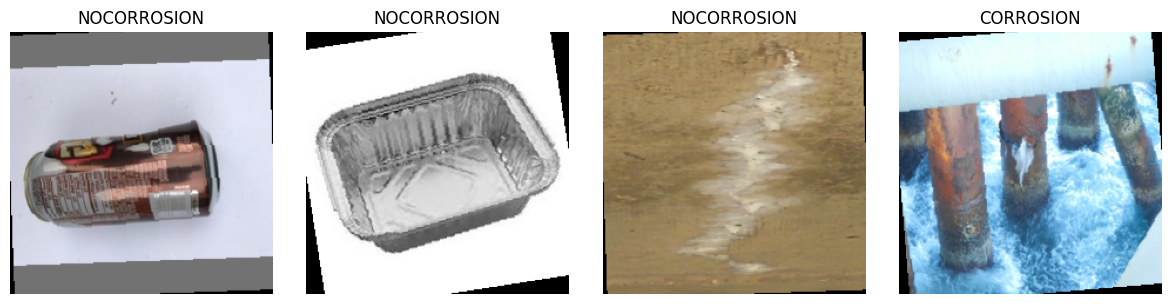

In [171]:
# Visual check

def denormalize(img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (img.cpu() * std + mean).clamp(0, 1)

images, labels = next(iter(train_dl_sup))

plt.figure(figsize=(12, 3))
for i in range(min(4, len(images))):
    plt.subplot(1, 4, i + 1)
    plt.imshow(denormalize(images[i]).permute(1, 2, 0))
    plt.title(CLASS_NAMES[labels[i].item()])
    plt.axis("off")
plt.tight_layout()
plt.show()

## Section 2 — Supervised Baseline (Cross-Entropy)

- ResNet18 with ImageNet weights
- Unfreeze `layer4` + replace FC head
- Train with cross-entropy on `train/CORROSION` + `train/NOCORROSION`
- Validate on `val/`
- OOD score: `max softmax probability` (overconfidence = bad)
- Feature score: cosine similarity to class prototypes from `avgpool`

In [172]:
def make_resnet18_full(num_classes):
    """Full ResNet18 fine-tuning — all weights trainable.
    Differential LR applied in optimizer: backbone 1e-4, head 1e-3.
    """
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


sup_model = make_resnet18_full(NUM_CLASSES).to(DEVICE)
print('Trainable params:', count_trainable_params(sup_model))

Trainable params: 11177538


In [173]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss, all_preds, all_labels = 0.0, [], []
    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return running_loss / len(dataloader.dataset), accuracy_score(all_labels, all_preds)


def eval_one_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss, all_preds, all_labels = 0.0, [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            loss   = criterion(logits, labels)
            running_loss += loss.item() * images.size(0)
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return running_loss / len(dataloader.dataset), accuracy_score(all_labels, all_preds)


def fit_supervised_model(model, train_loader, val_loader, criterion, optimizer,
                         device, epochs=10, checkpoint_path=None):
    history  = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_acc = -1.0
    best_state = None

    for epoch in range(epochs):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        vl_loss, vl_acc = eval_one_epoch(model, val_loader,   criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(vl_loss)
        history["val_acc"].append(vl_acc)

        print(f"Epoch {epoch+1:02d}/{epochs} | "
              f"train_loss={tr_loss:.4f} acc={tr_acc:.4f} | "
              f"val_loss={vl_loss:.4f} acc={vl_acc:.4f}")

        if vl_acc > best_acc:
            best_acc   = vl_acc
            best_state = deepcopy(model.state_dict())
            if checkpoint_path:
                torch.save(best_state, checkpoint_path)

    if best_state:
        model.load_state_dict(best_state)

    return model, history, best_acc

In [174]:
# Train supervised model — differential LR (backbone 1e-4, head 1e-3)

sup_criterion = nn.CrossEntropyLoss()
sup_optimizer = torch.optim.Adam([
    {'params': sup_model.fc.parameters(),                                      'lr': 1e-3},
    {'params': [p for n, p in sup_model.named_parameters() if 'fc' not in n], 'lr': 1e-4},
])

sup_model, sup_history, sup_best_val_acc = fit_supervised_model(
    sup_model, train_dl_sup, val_dl_sup, sup_criterion, sup_optimizer,
    DEVICE, epochs=SUP_EPOCHS, checkpoint_path='sup_best.pt'
)

print(f'\nBest supervised val acc: {sup_best_val_acc:.4f}')

Epoch 01/10 | train_loss=0.2739 acc=0.8743 | val_loss=0.2954 acc=0.8867
Epoch 02/10 | train_loss=0.1371 acc=0.9417 | val_loss=0.3137 acc=0.8959
Epoch 03/10 | train_loss=0.1139 acc=0.9552 | val_loss=0.4052 acc=0.8683
Epoch 04/10 | train_loss=0.0771 acc=0.9691 | val_loss=0.2908 acc=0.8989
Epoch 05/10 | train_loss=0.0924 acc=0.9631 | val_loss=0.6315 acc=0.8224
Epoch 06/10 | train_loss=0.0820 acc=0.9691 | val_loss=0.3909 acc=0.8821
Epoch 07/10 | train_loss=0.0736 acc=0.9703 | val_loss=0.3225 acc=0.9081
Epoch 08/10 | train_loss=0.0605 acc=0.9790 | val_loss=0.5390 acc=0.8698
Epoch 09/10 | train_loss=0.0808 acc=0.9691 | val_loss=0.3923 acc=0.8897
Epoch 10/10 | train_loss=0.0446 acc=0.9826 | val_loss=0.3656 acc=0.9005

Best supervised val acc: 0.9081


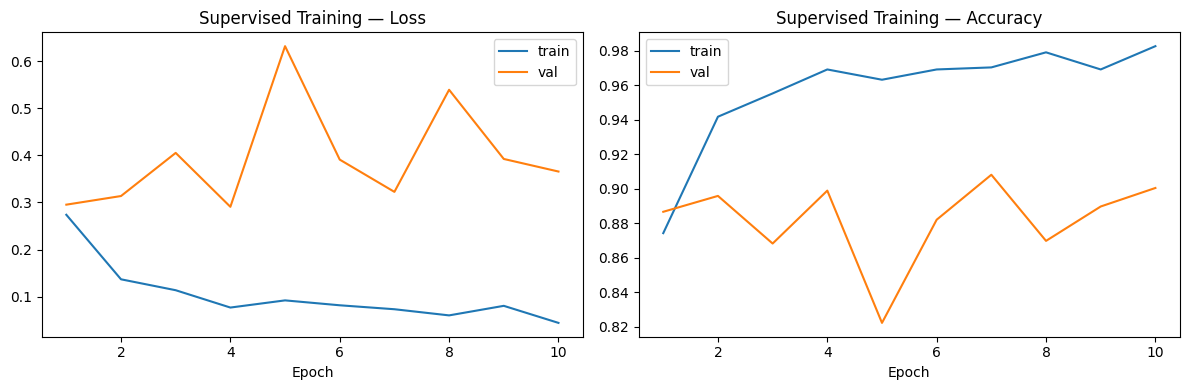

In [175]:
# Plot supervised training history

def plot_sup_history(history, title="Supervised Training"):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs, history["train_loss"], label="train")
    axes[0].plot(epochs, history["val_loss"],   label="val")
    axes[0].set_title(f"{title} — Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()
    axes[1].plot(epochs, history["train_acc"], label="train")
    axes[1].plot(epochs, history["val_acc"],   label="val")
    axes[1].set_title(f"{title} — Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

plot_sup_history(sup_history)

In [176]:
# Extract supervised features from avgpool

sup_feat_extractor = create_feature_extractor(
    sup_model, return_nodes={"avgpool": "emb"}
).to(DEVICE)
sup_feat_extractor.eval()


def extract_embeddings_resnet(feat_extractor, dataloader, device):
    feat_extractor.eval()
    all_emb, all_labels = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            emb    = feat_extractor(images)["emb"]
            emb    = torch.flatten(emb, start_dim=1)
            all_emb.append(emb.cpu())
            all_labels.append(labels.cpu())
    return torch.cat(all_emb, dim=0), torch.cat(all_labels, dim=0)


def l2_normalize_torch(Z, eps=1e-12):
    return Z / (Z.norm(dim=1, keepdim=True) + eps)


H_sup_train, y_train = extract_embeddings_resnet(sup_feat_extractor, train_dl_eval, DEVICE)
H_sup_val,   y_val   = extract_embeddings_resnet(sup_feat_extractor, val_dl_eval,   DEVICE)
H_sup_test,  y_test  = extract_embeddings_resnet(sup_feat_extractor, test_dl_eval,  DEVICE)
H_sup_vood,  _       = extract_embeddings_resnet(sup_feat_extractor, val_ood_dl,    DEVICE)
H_sup_tood,  _       = extract_embeddings_resnet(sup_feat_extractor, test_ood_dl,   DEVICE)

H_sup_train_l2 = l2_normalize_torch(H_sup_train)
H_sup_val_l2   = l2_normalize_torch(H_sup_val)
H_sup_test_l2  = l2_normalize_torch(H_sup_test)
H_sup_vood_l2  = l2_normalize_torch(H_sup_vood)
H_sup_tood_l2  = l2_normalize_torch(H_sup_tood)

print("Supervised features extracted.")
print(f"  train: {H_sup_train.shape}, val: {H_sup_val.shape}, test: {H_sup_test.shape}")
print(f"  val_ood: {H_sup_vood.shape}, test_ood: {H_sup_tood.shape}")

Supervised features extracted.
  train: torch.Size([2522, 512]), val: torch.Size([653, 512]), test: torch.Size([182, 512])
  val_ood: torch.Size([364, 512]), test_ood: torch.Size([850, 512])


Supervised test accuracy (ID): 0.9560

Classification Report (test set):
              precision    recall  f1-score   support

   CORROSION       0.97      0.95      0.96        99
 NOCORROSION       0.94      0.96      0.95        83

    accuracy                           0.96       182
   macro avg       0.96      0.96      0.96       182
weighted avg       0.96      0.96      0.96       182



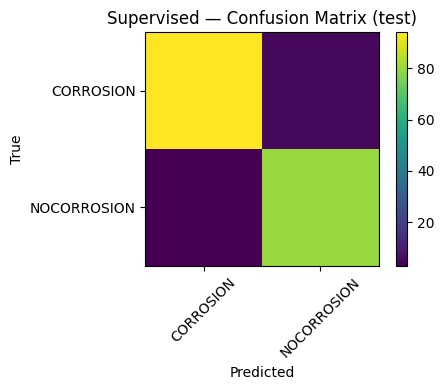

In [177]:
# Supervised — ID accuracy on test set

_, sup_test_acc = eval_one_epoch(sup_model, test_dl_eval, sup_criterion, DEVICE)
print(f"Supervised test accuracy (ID): {sup_test_acc:.4f}")

sup_model.eval()
sup_test_preds, sup_test_labels = [], []
with torch.no_grad():
    for images, labels in test_dl_eval:
        logits = sup_model(images.to(DEVICE))
        sup_test_preds.extend(logits.argmax(1).cpu().numpy())
        sup_test_labels.extend(labels.numpy())

print("\nClassification Report (test set):")
print(classification_report(sup_test_labels, sup_test_preds, target_names=CLASS_NAMES))

cm_sup = confusion_matrix(sup_test_labels, sup_test_preds)
plt.figure(figsize=(5, 4))
plt.imshow(cm_sup, interpolation="nearest")
plt.title("Supervised — Confusion Matrix (test)")
plt.colorbar()
tick_marks = np.arange(NUM_CLASSES)
plt.xticks(tick_marks, CLASS_NAMES, rotation=45)
plt.yticks(tick_marks, CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

## Section 3 — SimCLR + Linear Probe (Self-Supervised)

- ResNet18 backbone + 2-layer MLP projector
- Pretrained with NT-Xent loss on `train/CORROSION` + `train/NOCORROSION` only (no hard negatives)
- Linear probe trained on frozen encoder features

In [15]:
# SimCLR model — ResNet18 backbone + 2-layer MLP projector

class SimCLR(nn.Module):
    def __init__(self, proj_dim=128):
        super().__init__()
        base = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.encoder   = nn.Sequential(*list(base.children())[:-1])  # [B, 512, 1, 1]
        self.feat_dim  = base.fc.in_features  # 512
        self.projector = nn.Sequential(
            nn.Linear(self.feat_dim, self.feat_dim),
            nn.ReLU(),
            nn.Linear(self.feat_dim, proj_dim),
        )

    def forward(self, x):
        h = self.encoder(x).squeeze(-1).squeeze(-1)  # [B, 512]
        z = self.projector(h)                         # [B, proj_dim]
        return h, F.normalize(z, dim=1)

In [16]:
# NT-Xent loss

class NTXentLoss(nn.Module):
    def __init__(self, temperature=0.5):
        super().__init__()
        self.temp = temperature

    def forward(self, z1, z2):
        N   = z1.size(0)
        z   = torch.cat([z1, z2], dim=0)                     # [2N, D]
        sim = torch.mm(z, z.T) / self.temp                   # [2N, 2N]

        logits_max, _ = torch.max(sim, dim=1, keepdim=True)
        sim = sim - logits_max.detach()

        pos  = torch.cat([torch.diag(sim, N), torch.diag(sim, -N)])  # [2N]

        # Exclude self-similarity AND positive pairs from negatives
        mask = ~torch.eye(2 * N, dtype=torch.bool, device=z.device)
        mask[torch.arange(N), torch.arange(N) + N] = False   # i -> i+N
        mask[torch.arange(N) + N, torch.arange(N)] = False   # i+N -> i
        neg  = sim[mask].view(2 * N, -1)                     # [2N, 2N-2]

        logits = torch.cat([pos.unsqueeze(1), neg], dim=1)   # [2N, 2N-1]
        labels = torch.zeros(2 * N, dtype=torch.long, device=z.device)
        return F.cross_entropy(logits, labels)

In [17]:
# SimCLR training utilities

def train_simclr_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    for view_list, _ in dataloader:          # no labels here
        view1 = view_list[0].to(device)
        view2 = view_list[1].to(device)
        optimizer.zero_grad()
        _, z1 = model(view1)
        _, z2 = model(view2)
        loss  = criterion(z1, z2)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * view1.size(0)
    return running_loss / len(dataloader.dataset)


def fit_simclr(model, dataloader, criterion, optimizer, scheduler, device,
               epochs=20, checkpoint_path=None):
    history   = {"train_loss": []}
    best_loss = float("inf")
    best_state = None

    for epoch in range(epochs):
        loss = train_simclr_one_epoch(model, dataloader, criterion, optimizer, device)
        scheduler.step()
        history["train_loss"].append(loss)
        print(f"Epoch {epoch+1:02d}/{epochs} | loss={loss:.4f} | lr={optimizer.param_groups[0]['lr']:.6f}")

        if loss < best_loss:
            best_loss  = loss
            best_state = deepcopy(model.state_dict())
            if checkpoint_path:
                torch.save(best_state, checkpoint_path)

    if best_state:
        model.load_state_dict(best_state)


    return model, history, best_loss

In [18]:
# Train SimCLR — Adam lr=3e-4, temp=0.07, CosineAnnealingLR

simclr_model     = SimCLR(proj_dim=SIMCLR_PROJ_DIM).to(DEVICE)
simclr_criterion = NTXentLoss(temperature=SIMCLR_TEMP)
simclr_optimizer = torch.optim.Adam(
    simclr_model.parameters(),
    lr=SIMCLR_LR,
    weight_decay=1e-4,
)
simclr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    simclr_optimizer, T_max=SIMCLR_EPOCHS, eta_min=0
)

simclr_model, simclr_history, simclr_best_loss = fit_simclr(
    simclr_model, train_dl_simclr, simclr_criterion,
    simclr_optimizer, simclr_scheduler,
    DEVICE, epochs=SIMCLR_EPOCHS, checkpoint_path="simclr_best.pt"
)


print(f"\nBest SimCLR loss: {simclr_best_loss:.4f}")

Epoch 01/50 | loss=1.7377 | lr=0.000300
Epoch 02/50 | loss=0.8123 | lr=0.000299
Epoch 03/50 | loss=0.6002 | lr=0.000297
Epoch 04/50 | loss=0.5407 | lr=0.000295
Epoch 05/50 | loss=0.4825 | lr=0.000293
Epoch 06/50 | loss=0.4317 | lr=0.000289
Epoch 07/50 | loss=0.3929 | lr=0.000286
Epoch 08/50 | loss=0.3560 | lr=0.000281
Epoch 09/50 | loss=0.3392 | lr=0.000277
Epoch 10/50 | loss=0.3360 | lr=0.000271
Epoch 11/50 | loss=0.2983 | lr=0.000266
Epoch 12/50 | loss=0.2682 | lr=0.000259
Epoch 13/50 | loss=0.2539 | lr=0.000253
Epoch 14/50 | loss=0.2490 | lr=0.000246
Epoch 15/50 | loss=0.2437 | lr=0.000238
Epoch 16/50 | loss=0.2408 | lr=0.000230
Epoch 17/50 | loss=0.2113 | lr=0.000222
Epoch 18/50 | loss=0.1988 | lr=0.000214
Epoch 19/50 | loss=0.2047 | lr=0.000205
Epoch 20/50 | loss=0.2013 | lr=0.000196
Epoch 21/50 | loss=0.2032 | lr=0.000187
Epoch 22/50 | loss=0.1811 | lr=0.000178
Epoch 23/50 | loss=0.1836 | lr=0.000169
Epoch 24/50 | loss=0.1675 | lr=0.000159
Epoch 25/50 | loss=0.1561 | lr=0.000150


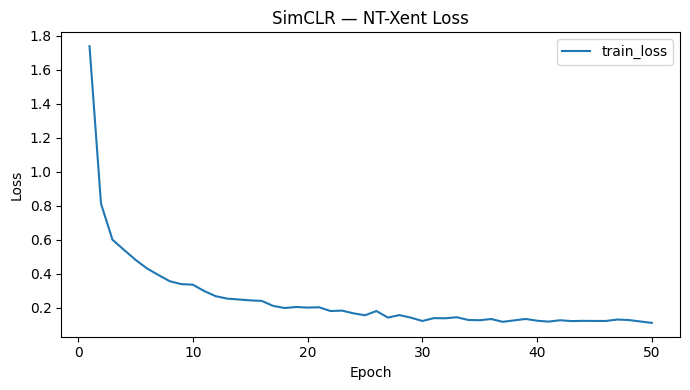

In [19]:
# Plot SimCLR training loss

def plot_contrastive_history(history, title="Contrastive Training"):
    epochs = range(1, len(history["train_loss"]) + 1)
    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_contrastive_history(simclr_history, title="SimCLR — NT-Xent Loss")

In [20]:
# Extract SimCLR backbone features (h = 512-dim, z = 128-dim projection)

def extract_embeddings_contrastive(model, dataloader, device):
    model.eval()
    all_h, all_z, all_labels = [], [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            h, z   = model(images)
            all_h.append(h.cpu())
            all_z.append(z.cpu())
            all_labels.append(labels.cpu())
    H = torch.cat(all_h, dim=0)
    Z = torch.cat(all_z, dim=0)
    y = torch.cat(all_labels, dim=0)
    return H, Z, y


H_simclr_train, _, y_train_check = extract_embeddings_contrastive(simclr_model, train_dl_eval, DEVICE)
H_simclr_val,   _, y_val_check   = extract_embeddings_contrastive(simclr_model, val_dl_eval,   DEVICE)
H_simclr_test,  _, y_test_check  = extract_embeddings_contrastive(simclr_model, test_dl_eval,  DEVICE)
H_simclr_vood,  _, _             = extract_embeddings_contrastive(simclr_model, val_ood_dl,    DEVICE)
H_simclr_tood,  _, _             = extract_embeddings_contrastive(simclr_model, test_ood_dl,   DEVICE)

H_simclr_train_l2 = l2_normalize_torch(H_simclr_train)
H_simclr_val_l2   = l2_normalize_torch(H_simclr_val)
H_simclr_test_l2  = l2_normalize_torch(H_simclr_test)
H_simclr_vood_l2  = l2_normalize_torch(H_simclr_vood)
H_simclr_tood_l2  = l2_normalize_torch(H_simclr_tood)

print("SimCLR features extracted.")
print(f"  train: {H_simclr_train.shape}, val: {H_simclr_val.shape}, test: {H_simclr_test.shape}")

SimCLR features extracted.
  train: torch.Size([2522, 512]), val: torch.Size([653, 512]), test: torch.Size([182, 512])


In [21]:
# Linear probe on SimCLR features

def run_linear_probe(Z_train, y_train, Z_val, y_val):
    clf = LogisticRegression(max_iter=2000, solver="lbfgs", class_weight="balanced")
    clf.fit(Z_train.numpy(), y_train.numpy())
    train_acc = accuracy_score(y_train.numpy(), clf.predict(Z_train.numpy()))
    val_acc   = accuracy_score(y_val.numpy(),   clf.predict(Z_val.numpy()))
    return clf, train_acc, val_acc


simclr_probe_clf, simclr_train_acc, simclr_val_acc = run_linear_probe(
    H_simclr_train_l2, y_train, H_simclr_val_l2, y_val
)

simclr_test_preds = simclr_probe_clf.predict(H_simclr_test_l2.numpy())
simclr_test_acc   = accuracy_score(y_test.numpy(), simclr_test_preds)

print(f"SimCLR linear probe — train={simclr_train_acc:.4f} | val={simclr_val_acc:.4f} | test={simclr_test_acc:.4f}")

SimCLR linear probe — train=0.9025 | val=0.8178 | test=0.9231


SimCLR — Classification Report (test set):
              precision    recall  f1-score   support

   CORROSION       0.91      0.95      0.93        99
 NOCORROSION       0.94      0.89      0.91        83

    accuracy                           0.92       182
   macro avg       0.92      0.92      0.92       182
weighted avg       0.92      0.92      0.92       182



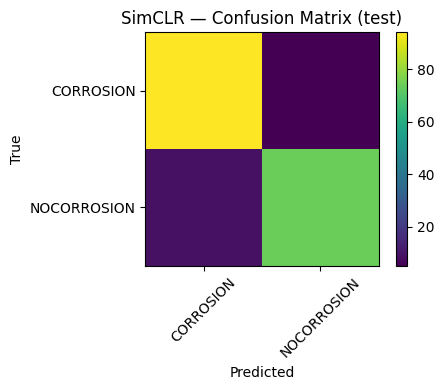

In [22]:
# SimCLR — ID test classification report

print("SimCLR — Classification Report (test set):")
print(classification_report(y_test.numpy(), simclr_test_preds, target_names=CLASS_NAMES))

cm_simclr = confusion_matrix(y_test.numpy(), simclr_test_preds)
plt.figure(figsize=(5, 4))
plt.imshow(cm_simclr, interpolation="nearest")
plt.title("SimCLR — Confusion Matrix (test)")
plt.colorbar()
tick_marks = np.arange(NUM_CLASSES)
plt.xticks(tick_marks, CLASS_NAMES, rotation=45)
plt.yticks(tick_marks, CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

## Section 4 — SupCon + Linear Probe (Supervised Contrastive)

- ResNet18 backbone + 2-layer MLP projector
- Trained with SupCon loss using class labels
- Positives: all images of the same class in the batch
- Linear probe on frozen backbone features `h`

In [87]:
print(SUPCON_EPOCHS)

100


In [88]:
# SupCon model —

class ResNet18SupCon(nn.Module):
    def __init__(self, proj_dim=128):
        super().__init__()
        base = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.encoder   = nn.Sequential(*list(base.children())[:-1])
        self.feat_dim  = base.fc.in_features  # 512
        self.projector = nn.Sequential(
            nn.Linear(self.feat_dim, self.feat_dim),
            nn.ReLU(),
            nn.Linear(self.feat_dim, proj_dim),
        )

    def forward(self, x):
        h = self.encoder(x).squeeze(-1).squeeze(-1)  # [B, 512]
        z = self.projector(h)                         # [B, proj_dim]
        return h, F.normalize(z, dim=1)

In [89]:
# Supervised Contrastive Loss

class SupConLoss(nn.Module):
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temp = temperature

    def forward(self, features, labels):
        """
        features: [B, 2, D] — two views per sample
        labels:   [B]
        """
        device = features.device
        B      = features.shape[0]

        f      = torch.cat(torch.unbind(features, dim=1), dim=0)  # [2B, D]
        f      = F.normalize(f, dim=1)
        labels = labels.repeat(2)                                  # [2B]

        sim = torch.mm(f, f.T) / self.temp

        logits_max, _ = torch.max(sim, dim=1, keepdim=True)
        sim = sim - logits_max.detach()

        labels_eq = labels.unsqueeze(0) == labels.unsqueeze(1)
        self_mask = ~torch.eye(2 * B, dtype=torch.bool, device=device)
        pos_mask  = labels_eq & self_mask

        exp_sim  = torch.exp(sim) * self_mask
        log_prob = sim - torch.log(exp_sim.sum(dim=1, keepdim=True) + 1e-12)

        mean_log_prob_pos = (pos_mask * log_prob).sum(dim=1) / (pos_mask.sum(dim=1) + 1e-12)
        return -mean_log_prob_pos.mean()

In [90]:
# SupCon training

def train_supcon_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    for view_list, labels in dataloader:
        view1  = view_list[0].to(device)
        view2  = view_list[1].to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        _, z1 = model(view1)
        _, z2 = model(view2)
        features = torch.stack([z1, z2], dim=1)  # [B, 2, D]
        loss     = criterion(features, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * view1.size(0)
    return running_loss / len(dataloader.dataset)


def fit_supcon(model, dataloader, criterion, optimizer, scheduler, device,
               epochs=20, checkpoint_path=None):
    history   = {"train_loss": [], "lr": []}
    best_loss = float("inf")
    best_state = None

    for epoch in range(epochs):
        loss = train_supcon_one_epoch(model, dataloader, criterion, optimizer, device)
        scheduler.step()
        history["train_loss"].append(loss)
        history["lr"].append(optimizer.param_groups[0]["lr"])
        print(f"Epoch {epoch+1:02d}/{epochs} | loss={loss:.4f} | lr={optimizer.param_groups[0]['lr']:.5f}")

        if loss < best_loss:
            best_loss  = loss
            best_state = deepcopy(model.state_dict())
            if checkpoint_path:
                torch.save(best_state, checkpoint_path)

    if best_state:
        model.load_state_dict(best_state)

    return model, history, best_loss

In [91]:
# Train SupCon
# Using SGD + momentum + cosine LR 

supcon_model     = ResNet18SupCon(proj_dim=SUPCON_PROJ_DIM).to(DEVICE)
supcon_criterion = SupConLoss(temperature=SUPCON_TEMP)

supcon_optimizer = torch.optim.SGD(
    supcon_model.parameters(),
    lr=SUPCON_LR,  
    momentum=0.9,
    weight_decay=1e-4,
)
supcon_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    supcon_optimizer, T_max=SUPCON_EPOCHS
)

supcon_model, supcon_history, supcon_best_loss = fit_supcon(
    supcon_model, train_dl_twocrop, supcon_criterion,
    supcon_optimizer, supcon_scheduler,
    DEVICE, epochs=SUPCON_EPOCHS, checkpoint_path="supcon_best.pt"
)

print(f"Best SupCon loss: {supcon_best_loss:.4f}")

Epoch 01/100 | loss=5.6173 | lr=0.12497
Epoch 02/100 | loss=5.4835 | lr=0.12488
Epoch 03/100 | loss=5.4357 | lr=0.12472
Epoch 04/100 | loss=5.4404 | lr=0.12451
Epoch 05/100 | loss=5.4169 | lr=0.12423
Epoch 06/100 | loss=5.3816 | lr=0.12389
Epoch 07/100 | loss=5.3750 | lr=0.12349
Epoch 08/100 | loss=5.3510 | lr=0.12304
Epoch 09/100 | loss=5.3503 | lr=0.12252
Epoch 10/100 | loss=5.3482 | lr=0.12194
Epoch 11/100 | loss=5.3406 | lr=0.12131
Epoch 12/100 | loss=5.3420 | lr=0.12061
Epoch 13/100 | loss=5.3114 | lr=0.11986
Epoch 14/100 | loss=5.3077 | lr=0.11905
Epoch 15/100 | loss=5.2862 | lr=0.11819
Epoch 16/100 | loss=5.2654 | lr=0.11727
Epoch 17/100 | loss=5.2976 | lr=0.11630
Epoch 18/100 | loss=5.2809 | lr=0.11527
Epoch 19/100 | loss=5.2906 | lr=0.11419
Epoch 20/100 | loss=5.2734 | lr=0.11306
Epoch 21/100 | loss=5.2773 | lr=0.11188
Epoch 22/100 | loss=5.2702 | lr=0.11066
Epoch 23/100 | loss=5.2622 | lr=0.10938
Epoch 24/100 | loss=5.2611 | lr=0.10806
Epoch 25/100 | loss=5.2465 | lr=0.10669


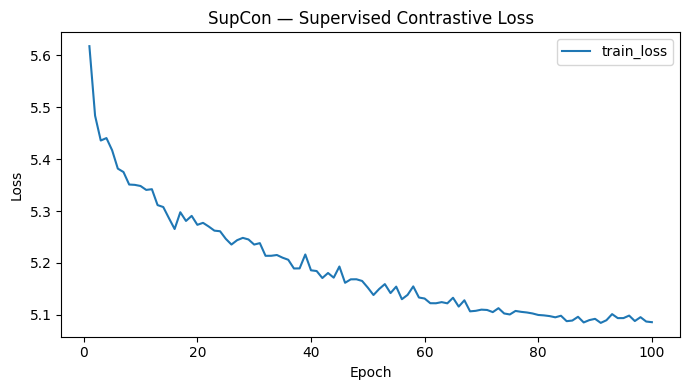

In [92]:
plot_contrastive_history(supcon_history, title="SupCon — Supervised Contrastive Loss")

In [93]:
# Extract SupCon features

H_supcon_train, _, _ = extract_embeddings_contrastive(supcon_model, train_dl_eval, DEVICE)
H_supcon_val,   _, _ = extract_embeddings_contrastive(supcon_model, val_dl_eval,   DEVICE)
H_supcon_test,  _, _ = extract_embeddings_contrastive(supcon_model, test_dl_eval,  DEVICE)
H_supcon_vood,  _, _ = extract_embeddings_contrastive(supcon_model, val_ood_dl,    DEVICE)
H_supcon_tood,  _, _ = extract_embeddings_contrastive(supcon_model, test_ood_dl,   DEVICE)

H_supcon_train_l2 = l2_normalize_torch(H_supcon_train)
H_supcon_val_l2   = l2_normalize_torch(H_supcon_val)
H_supcon_test_l2  = l2_normalize_torch(H_supcon_test)
H_supcon_vood_l2  = l2_normalize_torch(H_supcon_vood)
H_supcon_tood_l2  = l2_normalize_torch(H_supcon_tood)

print("SupCon features extracted.")
print(f"  train: {H_supcon_train.shape}, val: {H_supcon_val.shape}, test: {H_supcon_test.shape}")

SupCon features extracted.
  train: torch.Size([2522, 512]), val: torch.Size([653, 512]), test: torch.Size([182, 512])


In [94]:
# Linear probe on SupCon features

supcon_probe_clf, supcon_train_acc, supcon_val_acc = run_linear_probe(
    H_supcon_train_l2, y_train, H_supcon_val_l2, y_val
)

supcon_test_preds = supcon_probe_clf.predict(H_supcon_test_l2.numpy())
supcon_test_acc   = accuracy_score(y_test.numpy(), supcon_test_preds)

print(f"SupCon linear probe — train={supcon_train_acc:.4f} | val={supcon_val_acc:.4f} | test={supcon_test_acc:.4f}")

SupCon linear probe — train=0.9980 | val=0.8668 | test=0.9176


SupCon — Classification Report (test set):
              precision    recall  f1-score   support

   CORROSION       0.93      0.92      0.92        99
 NOCORROSION       0.90      0.92      0.91        83

    accuracy                           0.92       182
   macro avg       0.92      0.92      0.92       182
weighted avg       0.92      0.92      0.92       182



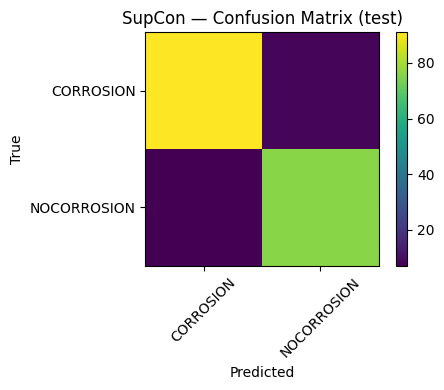

In [95]:
# SupCon — ID test classification report

print("SupCon — Classification Report (test set):")
print(classification_report(y_test.numpy(), supcon_test_preds, target_names=CLASS_NAMES))

cm_supcon = confusion_matrix(y_test.numpy(), supcon_test_preds)
plt.figure(figsize=(5, 4))
plt.imshow(cm_supcon, interpolation="nearest")
plt.title("SupCon — Confusion Matrix (test)")
plt.colorbar()
tick_marks = np.arange(NUM_CLASSES)
plt.xticks(tick_marks, CLASS_NAMES, rotation=45)
plt.yticks(tick_marks, CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

## Section 4b — BYOL + Linear Probe (SSL + no negatives)

- Two networks: **online** (encoder + projector + predictor) and **target** (encoder + projector, EMA copy)
- No negative pairs
- Loss: normalized MSE
- EMA decay τ=0.996, updated every step
- Linear probe trained on frozen online encoder features `h`

In [31]:
# BYOL config
BYOL_PROJ_DIM  = 256    # projector output dim
BYOL_PRED_DIM  = 256    # predictor output dim
BYOL_HIDDEN    = 512   # hidden dim in projector/predictor
BYOL_LR        = 3e-4  
BYOL_EPOCHS    = 50
BYOL_BATCH     = 128
BYOL_EMA_DECAY = 0.999  # τ — official value, updated per step

print(f'BYOL config: proj_dim={BYOL_PROJ_DIM}, hidden={BYOL_HIDDEN}, lr={BYOL_LR}, ema={BYOL_EMA_DECAY}')

BYOL config: proj_dim=256, hidden=512, lr=0.0003, ema=0.999


In [32]:
# BYOL DataLoader — reuses two_crop_tf already defined
train_dl_byol = DataLoader(
    train_ds_twocrop, batch_size=BYOL_BATCH,
    shuffle=True, num_workers=NUM_WORKERS, drop_last=True
)
print('BYOL dataloader ready. Batches per epoch:', len(train_dl_byol))

BYOL dataloader ready. Batches per epoch: 19


In [ ]:
# BYOL Architecture
# online network: encoder -> projector -> predictor
# target network: encoder -> projector 

class MLP(nn.Module):
    """2-layer MLP with BatchNorm: in_dim -> hidden_dim (BN+ReLU) -> out_dim"""
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, out_dim),
        )
    def forward(self, x):
        return self.net(x)


class BYOLEncoder(nn.Module):
    """ResNet18 backbone + projector MLP"""
    def __init__(self, proj_dim=256, hidden_dim=4096):
        super().__init__()
        base       = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.encoder   = nn.Sequential(*list(base.children())[:-1])  # [B, 512, 1, 1]
        self.feat_dim  = base.fc.in_features  # 512
        self.projector = MLP(self.feat_dim, hidden_dim, proj_dim)

    def forward(self, x):
        h = self.encoder(x).squeeze(-1).squeeze(-1)  # [B, 512]
        z = self.projector(h)                         # [B, proj_dim]
        return h, z


class BYOL(nn.Module):
    def __init__(self, proj_dim=256, hidden_dim=4096):
        super().__init__()
        # Online network: encoder + projector + predictor
        self.online_encoder   = BYOLEncoder(proj_dim, hidden_dim)
        self.online_predictor = MLP(proj_dim, hidden_dim, proj_dim)

        # Target network: encoder + projector only (EMA)
        self.target_encoder   = BYOLEncoder(proj_dim, hidden_dim)

        # Initialise target with same weights as online
        self.target_encoder.load_state_dict(self.online_encoder.state_dict())

        # Target never receives gradients
        for p in self.target_encoder.parameters():
            p.requires_grad = False

    @torch.no_grad()
    def update_target(self, decay):
        """EMA update: target <- decay*target + (1-decay)*online"""
        for p_online, p_target in zip(
            self.online_encoder.parameters(),
            self.target_encoder.parameters()
        ):
            p_target.data = decay * p_target.data + (1.0 - decay) * p_online.data

    def forward(self, x1, x2):
        # Online forward
        _, z1_online = self.online_encoder(x1)
        _, z2_online = self.online_encoder(x2)
        q1 = self.online_predictor(z1_online)  # [B, proj_dim]
        q2 = self.online_predictor(z2_online)

        # Target forward (no grad)
        with torch.no_grad():
            _, z1_target = self.target_encoder(x1)
            _, z2_target = self.target_encoder(x2)

        return q1, q2, z1_target.detach(), z2_target.detach()

    def get_features(self, x):
        """Extract backbone features for downstream evaluation"""
        h, _ = self.online_encoder(x)
        return h


# check
_byol_test = BYOL(proj_dim=BYOL_PROJ_DIM, hidden_dim=BYOL_HIDDEN).to(DEVICE)
_x = torch.randn(4, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
_q1, _q2, _z1, _z2 = _byol_test(_x, _x)
print('BYOL architecture OK')
print(f'  q (predictor out): {_q1.shape}')
print(f'  z (target out):    {_z1.shape}')
del _byol_test, _x, _q1, _q2, _z1, _z2

BYOL architecture OK
  q (predictor out): torch.Size([4, 256])
  z (target out):    torch.Size([4, 256])


In [34]:
# BYOL Loss — normalized MSE = negative cosine similarity
# Computed bidirectionally

def byol_loss(q, z):
    """
    q: predictor output from online network  [B, D]
    z: projector output from target network  [B, D]
    returns scalar loss (negative cosine similarity, mean over batch)
    """
    q = F.normalize(q, dim=1)
    z = F.normalize(z, dim=1)
    return 2 - 2 * (q * z).sum(dim=1).mean()  # range [0, 4], optimal=0

In [35]:
# BYOL training utilities

def train_byol_one_epoch(model, dataloader, optimizer, device, ema_decay):
    model.train()
    running_loss = 0.0
    for view_list, _ in dataloader:          # labels ignored
        x1 = view_list[0].to(device)
        x2 = view_list[1].to(device)

        optimizer.zero_grad()
        q1, q2, z1_target, z2_target = model(x1, x2)

        # Bidirectional loss
        loss = (byol_loss(q1, z2_target) + byol_loss(q2, z1_target)) * 0.5
        loss.backward()
        optimizer.step()

        # EMA update after every step
        model.update_target(ema_decay)

        running_loss += loss.item() * x1.size(0)
    return running_loss / len(dataloader.dataset)


def fit_byol(model, dataloader, optimizer, scheduler, device,
             epochs=50, ema_decay=0.996, checkpoint_path=None):
    history   = {'train_loss': []}
    best_loss = float('inf')
    best_state = None

    for epoch in range(epochs):
        loss = train_byol_one_epoch(model, dataloader, optimizer, device, ema_decay)
        scheduler.step()
        history['train_loss'].append(loss)
        print(f'Epoch {epoch+1:02d}/{epochs} | loss={loss:.4f} | lr={optimizer.param_groups[0]["lr"]:.6f}')

        if loss < best_loss:
            best_loss  = loss
            best_state = deepcopy(model.state_dict())
            if checkpoint_path:
                torch.save(best_state, checkpoint_path)

    if best_state:
        model.load_state_dict(best_state)

    return model, history, best_loss

In [36]:
# Train BYOL
# Adam + CosineAnnealingLR

byol_model     = BYOL(proj_dim=BYOL_PROJ_DIM, hidden_dim=BYOL_HIDDEN).to(DEVICE)
byol_optimizer = torch.optim.Adam(
    list(byol_model.online_encoder.parameters()) +
    list(byol_model.online_predictor.parameters()),
    lr=BYOL_LR,
    weight_decay=1e-4,
)
byol_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    byol_optimizer, T_max=BYOL_EPOCHS, eta_min=0
)

byol_model, byol_history, byol_best_loss = fit_byol(
    byol_model, train_dl_byol, byol_optimizer, byol_scheduler,
    DEVICE, epochs=BYOL_EPOCHS, ema_decay=BYOL_EMA_DECAY,
    checkpoint_path='byol_best.pt'
)

print(f'\nBest BYOL loss: {byol_best_loss:.4f}')

Epoch 01/50 | loss=1.0987 | lr=0.000300
Epoch 02/50 | loss=0.7461 | lr=0.000299
Epoch 03/50 | loss=0.6911 | lr=0.000297
Epoch 04/50 | loss=0.6609 | lr=0.000295
Epoch 05/50 | loss=0.6369 | lr=0.000293
Epoch 06/50 | loss=0.6153 | lr=0.000289
Epoch 07/50 | loss=0.5955 | lr=0.000286
Epoch 08/50 | loss=0.5801 | lr=0.000281
Epoch 09/50 | loss=0.5646 | lr=0.000277
Epoch 10/50 | loss=0.5479 | lr=0.000271
Epoch 11/50 | loss=0.5316 | lr=0.000266
Epoch 12/50 | loss=0.5151 | lr=0.000259
Epoch 13/50 | loss=0.5029 | lr=0.000253
Epoch 14/50 | loss=0.4903 | lr=0.000246
Epoch 15/50 | loss=0.4766 | lr=0.000238
Epoch 16/50 | loss=0.4668 | lr=0.000230
Epoch 17/50 | loss=0.4512 | lr=0.000222
Epoch 18/50 | loss=0.4437 | lr=0.000214
Epoch 19/50 | loss=0.4313 | lr=0.000205
Epoch 20/50 | loss=0.4208 | lr=0.000196
Epoch 21/50 | loss=0.4092 | lr=0.000187
Epoch 22/50 | loss=0.4031 | lr=0.000178
Epoch 23/50 | loss=0.3929 | lr=0.000169
Epoch 24/50 | loss=0.3744 | lr=0.000159
Epoch 25/50 | loss=0.3734 | lr=0.000150


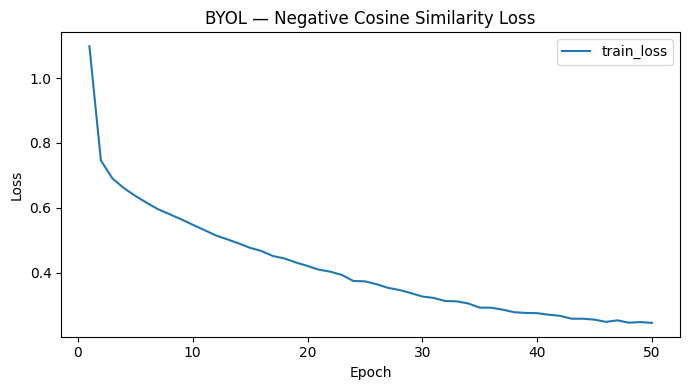

In [37]:
plot_contrastive_history(byol_history, title='BYOL — Negative Cosine Similarity Loss')

In [38]:
# Extract BYOL features from online encoder backbone

def extract_byol_features(model, dataloader, device):
    model.eval()
    all_h, all_labels = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            h      = model.get_features(images)
            all_h.append(h.cpu())
            all_labels.append(labels.cpu())
    return torch.cat(all_h, dim=0), torch.cat(all_labels, dim=0)


H_byol_train, _       = extract_byol_features(byol_model, train_dl_eval, DEVICE)
H_byol_val,   _       = extract_byol_features(byol_model, val_dl_eval,   DEVICE)
H_byol_test,  _       = extract_byol_features(byol_model, test_dl_eval,  DEVICE)
H_byol_vood,  _       = extract_byol_features(byol_model, val_ood_dl,    DEVICE)
H_byol_tood,  _       = extract_byol_features(byol_model, test_ood_dl,   DEVICE)

H_byol_train_l2 = l2_normalize_torch(H_byol_train)
H_byol_val_l2   = l2_normalize_torch(H_byol_val)
H_byol_test_l2  = l2_normalize_torch(H_byol_test)
H_byol_vood_l2  = l2_normalize_torch(H_byol_vood)
H_byol_tood_l2  = l2_normalize_torch(H_byol_tood)

print('BYOL features extracted.')
print(f'  train: {H_byol_train.shape}, val: {H_byol_val.shape}, test: {H_byol_test.shape}')

BYOL features extracted.
  train: torch.Size([2522, 512]), val: torch.Size([653, 512]), test: torch.Size([182, 512])


In [39]:
# Linear probe on BYOL features

byol_probe_clf, byol_train_acc, byol_val_acc = run_linear_probe(
    H_byol_train_l2, y_train, H_byol_val_l2, y_val
)

byol_test_preds = byol_probe_clf.predict(H_byol_test_l2.numpy())
byol_test_acc   = accuracy_score(y_test.numpy(), byol_test_preds)

print(f'BYOL linear probe — train={byol_train_acc:.4f} | val={byol_val_acc:.4f} | test={byol_test_acc:.4f}')

BYOL linear probe — train=0.9266 | val=0.8714 | test=0.9341


BYOL — Classification Report (test set):
              precision    recall  f1-score   support

   CORROSION       0.94      0.94      0.94        99
 NOCORROSION       0.93      0.93      0.93        83

    accuracy                           0.93       182
   macro avg       0.93      0.93      0.93       182
weighted avg       0.93      0.93      0.93       182



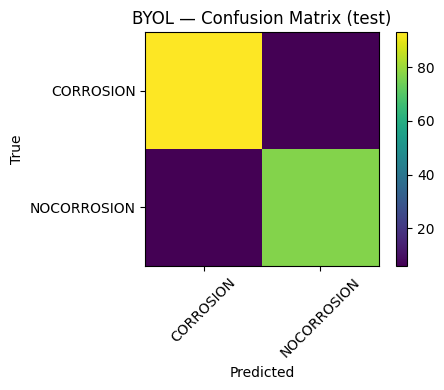

In [40]:
# BYOL — ID test classification report

print('BYOL — Classification Report (test set):')
print(classification_report(y_test.numpy(), byol_test_preds, target_names=CLASS_NAMES))

cm_byol = confusion_matrix(y_test.numpy(), byol_test_preds)
plt.figure(figsize=(5, 4))
plt.imshow(cm_byol, interpolation='nearest')
plt.title('BYOL — Confusion Matrix (test)')
plt.colorbar()
tick_marks = np.arange(NUM_CLASSES)
plt.xticks(tick_marks, CLASS_NAMES, rotation=45)
plt.yticks(tick_marks, CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

## Section 5 — OOD Evaluation


Two scoring methods for each model:

1. **Softmax score** — `max(p(corrosion), p(nocorrosion))`  
   High = confident ID, Low = likely OOD  
   (Supervised: from model logits; contrastive: from linear probe)

2. **Feature distance score** — `max cosine similarity to class prototypes`  
   High = close to a known class center, Low = likely OOD  









**In Distribution (ID) Test Accuracy** : **higher better**

**Softmax AUROC** **higher better(how well classes are seperated)**

**Feature AUROC** **higher better(how well classes are seperated)**

**OOD Reject Rate** : How many hard negatives get rejected at the tuned threshold <- based on threshold
**% OOD as Corrosion** : How often does the model confuse OOD with corrosion

**Mean P(corr) on OOD** : How overconfident is the model on OOD

In [178]:
#compute class prototypes from training features

def compute_class_prototypes(Z, y, num_classes):
    prototypes = []
    for c in range(num_classes):
        mask  = (y == c)
        proto = Z[mask].mean(dim=0)
        prototypes.append(proto)
    return torch.stack(prototypes, dim=0)  # [C, D]


# cosine similarity score to nearest prototype
def cosine_confidence_scores(Z_l2, prototypes_l2):
    """
    Z_l2:           [N, D] L2-normalized features
    prototypes_l2:  [C, D] L2-normalized prototypes
    returns:        [N] max cosine similarity to any class prototype
    """
    sims = torch.mm(Z_l2, prototypes_l2.T)  # [N, C]
    return sims.max(dim=1).values            # [N]

In [179]:
# Build prototypes for each method from training features

proto_sup    = l2_normalize_torch(compute_class_prototypes(H_sup_train_l2,    y_train, NUM_CLASSES))
proto_simclr = l2_normalize_torch(compute_class_prototypes(H_simclr_train_l2, y_train, NUM_CLASSES))
proto_supcon = l2_normalize_torch(compute_class_prototypes(H_supcon_train_l2, y_train, NUM_CLASSES))
proto_byol   = l2_normalize_torch(compute_class_prototypes(H_byol_train_l2,   y_train, NUM_CLASSES))

print("Prototypes computed.")
print(f"  supervised: {proto_sup.shape}")
print(f"  simclr:     {proto_simclr.shape}")
print(f"  supcon:     {proto_supcon.shape}")
print(f"  byol:       {proto_byol.shape}")

Prototypes computed.
  supervised: torch.Size([2, 512])
  simclr:     torch.Size([2, 512])
  supcon:     torch.Size([2, 512])
  byol:       torch.Size([2, 512])


In [180]:
# Softmax scores
# use linear probe
# Softmax score = max probability across classes

# Supervised — get softmax from the trained classifier (just the logits)
sup_model.eval()
sup_softmax_test, sup_softmax_tood = [], []

with torch.no_grad():
    for images, _ in test_dl_eval:
        logits = sup_model(images.to(DEVICE))
        probs  = F.softmax(logits, dim=1)
        sup_softmax_test.append(probs.cpu())
    for images, _ in test_ood_dl:
        logits = sup_model(images.to(DEVICE))
        probs  = F.softmax(logits, dim=1)
        sup_softmax_tood.append(probs.cpu())

sup_softmax_test = torch.cat(sup_softmax_test, dim=0)  # [N_id, C]
sup_softmax_tood = torch.cat(sup_softmax_tood, dim=0)  # [N_ood, C]

sup_score_test  = sup_softmax_test.max(dim=1).values.numpy()   # max softmax ID
sup_score_tood  = sup_softmax_tood.max(dim=1).values.numpy()   # max softmax OOD
sup_corr_prob_tood = sup_softmax_tood[:, CORROSION_IDX].numpy()  # P(corrosion) on OOD

print(f"Supervised softmax — ID mean={sup_score_test.mean():.4f}, OOD mean={sup_score_tood.mean():.4f}")

Supervised softmax — ID mean=0.9810, OOD mean=0.9025


In [181]:
# SimCLR softmax scores from linear probe
simclr_prob_test = simclr_probe_clf.predict_proba(H_simclr_test_l2.numpy())
simclr_prob_tood = simclr_probe_clf.predict_proba(H_simclr_tood_l2.numpy())
simclr_score_test     = simclr_prob_test.max(axis=1)
simclr_score_tood     = simclr_prob_tood.max(axis=1)
simclr_corr_prob_tood = simclr_prob_tood[:, CORROSION_IDX]
print(f"SimCLR softmax — ID mean={simclr_score_test.mean():.4f}, OOD mean={simclr_score_tood.mean():.4f}")

# SupCon softmax scores from linear probe
supcon_prob_test = supcon_probe_clf.predict_proba(H_supcon_test_l2.numpy())
supcon_prob_tood = supcon_probe_clf.predict_proba(H_supcon_tood_l2.numpy())
supcon_score_test     = supcon_prob_test.max(axis=1)
supcon_score_tood     = supcon_prob_tood.max(axis=1)
supcon_corr_prob_tood = supcon_prob_tood[:, CORROSION_IDX]
print(f"SupCon softmax — ID mean={supcon_score_test.mean():.4f}, OOD mean={supcon_score_tood.mean():.4f}")

# BYOL softmax scores from linear probe
byol_prob_test = byol_probe_clf.predict_proba(H_byol_test_l2.numpy())
byol_prob_tood = byol_probe_clf.predict_proba(H_byol_tood_l2.numpy())
byol_score_test     = byol_prob_test.max(axis=1)
byol_score_tood     = byol_prob_tood.max(axis=1)
byol_corr_prob_tood = byol_prob_tood[:, CORROSION_IDX]
print(f"BYOL softmax   — ID mean={byol_score_test.mean():.4f}, OOD mean={byol_score_tood.mean():.4f}")
print()
print('id higher better ood lower better')

SimCLR softmax — ID mean=0.8121, OOD mean=0.7534
SupCon softmax — ID mean=0.9448, OOD mean=0.8541
BYOL softmax   — ID mean=0.8370, OOD mean=0.7738

id higher better ood lower better


In [182]:
# Feature distance scores (cos similarity to class)

sup_feat_test  = cosine_confidence_scores(H_sup_test_l2,    proto_sup)
sup_feat_tood  = cosine_confidence_scores(H_sup_tood_l2,    proto_sup)

simclr_feat_test = cosine_confidence_scores(H_simclr_test_l2, proto_simclr)
simclr_feat_tood = cosine_confidence_scores(H_simclr_tood_l2, proto_simclr)

supcon_feat_test = cosine_confidence_scores(H_supcon_test_l2, proto_supcon)
supcon_feat_tood = cosine_confidence_scores(H_supcon_tood_l2, proto_supcon)

byol_feat_test = cosine_confidence_scores(H_byol_test_l2, proto_byol)
byol_feat_tood = cosine_confidence_scores(H_byol_tood_l2, proto_byol)

print("Feature distance scores:")
print(f"  Supervised — ID mean={sup_feat_test.mean():.4f},    OOD mean={sup_feat_tood.mean():.4f}")
print(f"  SimCLR     — ID mean={simclr_feat_test.mean():.4f}, OOD mean={simclr_feat_tood.mean():.4f}")
print(f"  SupCon     — ID mean={supcon_feat_test.mean():.4f}, OOD mean={supcon_feat_tood.mean():.4f}")
print(f"  BYOL       — ID mean={byol_feat_test.mean():.4f},   OOD mean={byol_feat_tood.mean():.4f}")

Feature distance scores:
  Supervised — ID mean=0.8326,    OOD mean=0.6984
  SimCLR     — ID mean=0.7314, OOD mean=0.6534
  SupCon     — ID mean=0.8104, OOD mean=0.6888
  BYOL       — ID mean=0.7185,   OOD mean=0.6661


In [183]:
# OOD utility functions

def compute_auroc(id_scores, ood_scores):
    """AUROC for separating ID (label=1) from OOD (label=0)."""
    scores = np.concatenate([id_scores, ood_scores])
    labels = np.concatenate([np.ones(len(id_scores)), np.zeros(len(ood_scores))])
    return roc_auc_score(labels, scores)


def tune_threshold(id_feat_val, y_val_np, ood_feat_vood, proto, steps=50):
    """
    Sweep thresholds on val_ood to find best operating point.
    Returns DataFrame: (threshold, id_coverage, id_accepted_acc, ood_reject_rate)
    """
    id_scores  = cosine_confidence_scores(id_feat_val,   proto).numpy()
    ood_scores = cosine_confidence_scores(ood_feat_vood, proto).numpy()
    id_preds   = torch.mm(id_feat_val, proto.T).argmax(dim=1).numpy()

    all_scores = np.concatenate([id_scores, ood_scores])
    thresholds = np.linspace(all_scores.min(), all_scores.max(), steps)

    rows = []
    for t in thresholds:
        id_accept  = id_scores  >= t
        ood_reject = ood_scores <  t
        coverage     = id_accept.mean()
        ood_rej_rate = ood_reject.mean()
        acc = accuracy_score(y_val_np[id_accept], id_preds[id_accept]) if id_accept.sum() > 0 else float("nan")
        rows.append({
            "threshold":       float(t),
            "id_coverage":     float(coverage),
            "id_accepted_acc": float(acc),
            "ood_reject_rate": float(ood_rej_rate),
        })
    return pd.DataFrame(rows)


def best_threshold(df, min_coverage=0.80):
    """Select threshold with highest OOD reject rate while keeping ID coverage >= min_coverage."""
    valid = df[df["id_coverage"] >= min_coverage].dropna()
    if valid.empty:
        return float(df.iloc[0]["threshold"])
    return float(valid.sort_values("ood_reject_rate", ascending=False).iloc[0]["threshold"])


def eval_ood_final(id_feat_test, y_test_np, ood_feat_tood, proto, threshold, name):
    """Final OOD evaluation on test_ood using selected threshold."""
    id_scores  = cosine_confidence_scores(id_feat_test,  proto).numpy()
    ood_scores = cosine_confidence_scores(ood_feat_tood, proto).numpy()
    id_preds   = torch.mm(id_feat_test, proto.T).argmax(dim=1).numpy()

    auroc = compute_auroc(id_scores, ood_scores)

    id_accept       = id_scores  >= threshold
    ood_reject      = ood_scores <  threshold
    id_coverage     = id_accept.mean()
    ood_reject_rate = ood_reject.mean()
    id_acc_at_t     = accuracy_score(y_test_np[id_accept], id_preds[id_accept]) if id_accept.sum() > 0 else float("nan")

    print()
    print(f"  {name}")
    print()
    print(f"  Feature AUROC (ID vs OOD): {auroc:.4f}")
    print(f"  Threshold:                 {threshold:.4f}")
    print(f"  ID coverage:               {id_coverage:.4f}")
    print(f"  Accepted ID accuracy:      {id_acc_at_t:.4f}")
    print(f"  OOD reject rate:           {ood_reject_rate:.4f}")

    return {
        "method":          name,
        "feat_auroc":      auroc,
        "threshold":       threshold,
        "id_coverage":     id_coverage,
        "id_acc_at_t":     id_acc_at_t,
        "ood_reject_rate": ood_reject_rate,
    }


def visualize_feature_space(H_test, y_test_np, H_tood, class_names, title):
    """PCA scatter plot of test (ID) + OOD features."""
    from sklearn.decomposition import PCA
    Z_all = np.concatenate([H_test.numpy(), H_tood.numpy()], axis=0)
    y_all = np.concatenate([y_test_np, np.full(len(H_tood), len(class_names))])

    pca  = PCA(n_components=2)
    Z_2d = pca.fit_transform(Z_all)

    plt.figure(figsize=(6, 5))
    for c, cname in enumerate(class_names):
        mask = y_all == c
        plt.scatter(Z_2d[mask, 0], Z_2d[mask, 1], alpha=0.6, label=cname)
    mask_ood = y_all == len(class_names)
    plt.scatter(Z_2d[mask_ood, 0], Z_2d[mask_ood, 1], alpha=0.5,
                marker="x", color="red", label="OOD")
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [184]:
# AUROC — how well each score separates ID from OOD

auroc_sup_softmax    = compute_auroc(sup_score_test,    sup_score_tood)
auroc_simclr_softmax = compute_auroc(simclr_score_test, simclr_score_tood)
auroc_supcon_softmax = compute_auroc(supcon_score_test, supcon_score_tood)
auroc_byol_softmax   = compute_auroc(byol_score_test,   byol_score_tood)

auroc_sup_feat    = compute_auroc(sup_feat_test.numpy(),    sup_feat_tood.numpy())
auroc_simclr_feat = compute_auroc(simclr_feat_test.numpy(), simclr_feat_tood.numpy())
auroc_supcon_feat = compute_auroc(supcon_feat_test.numpy(), supcon_feat_tood.numpy())
auroc_byol_feat   = compute_auroc(byol_feat_test.numpy(),   byol_feat_tood.numpy())

print("AUROC (ID vs OOD separation)")
print()
print(f"{'Method':<20} {'Softmax AUROC':>15} {'Feature AUROC':>15}")
print()
print(f"{'Supervised':<20} {auroc_sup_softmax:>15.4f} {auroc_sup_feat:>15.4f}")
print(f"{'SimCLR':<20} {auroc_simclr_softmax:>15.4f} {auroc_simclr_feat:>15.4f}")
print(f"{'SupCon':<20} {auroc_supcon_softmax:>15.4f} {auroc_supcon_feat:>15.4f}")
print(f"{'BYOL':<20} {auroc_byol_softmax:>15.4f} {auroc_byol_feat:>15.4f}")

AUROC (ID vs OOD separation)

Method                 Softmax AUROC   Feature AUROC

Supervised                    0.8022          0.8734
SimCLR                        0.6296          0.8252
SupCon                        0.7749          0.8192
BYOL                          0.6409          0.7372


In [185]:
# % of OOD samples predicted as CORROSION (overconfidence check)

sup_ood_as_corr    = (sup_model(torch.stack([test_ood_ds[i][0] for i in range(len(test_ood_ds))]).to(DEVICE))
                      .argmax(1) == CORROSION_IDX).float().mean().item()
simclr_ood_preds   = simclr_probe_clf.predict(H_simclr_tood_l2.numpy())
simclr_ood_as_corr = (simclr_ood_preds == CORROSION_IDX).mean()
supcon_ood_preds   = supcon_probe_clf.predict(H_supcon_tood_l2.numpy())
supcon_ood_as_corr = (supcon_ood_preds == CORROSION_IDX).mean()
byol_ood_preds     = byol_probe_clf.predict(H_byol_tood_l2.numpy())
byol_ood_as_corr   = (byol_ood_preds == CORROSION_IDX).mean()

print("% of OOD samples predicted as CORROSION (lower is better):")
print(f"  Supervised: {sup_ood_as_corr*100:.1f}%")
print(f"  SimCLR:     {simclr_ood_as_corr*100:.1f}%")
print(f"  SupCon:     {supcon_ood_as_corr*100:.1f}%")
print(f"  BYOL:       {byol_ood_as_corr*100:.1f}%")

print("\nMean P(corrosion) on OOD samples (lower = more uncertain/correct):")
print(f"  Supervised: {sup_corr_prob_tood.mean():.4f}")
print(f"  SimCLR:     {simclr_corr_prob_tood.mean():.4f}")
print(f"  SupCon:     {supcon_corr_prob_tood.mean():.4f}")
print(f"  BYOL:       {byol_corr_prob_tood.mean():.4f}")

% of OOD samples predicted as CORROSION (lower is better):
  Supervised: 56.1%
  SimCLR:     53.3%
  SupCon:     69.3%
  BYOL:       59.8%

Mean P(corrosion) on OOD samples (lower = more uncertain/correct):
  Supervised: 0.5709
  SimCLR:     0.5144
  SupCon:     0.6554
  BYOL:       0.5761


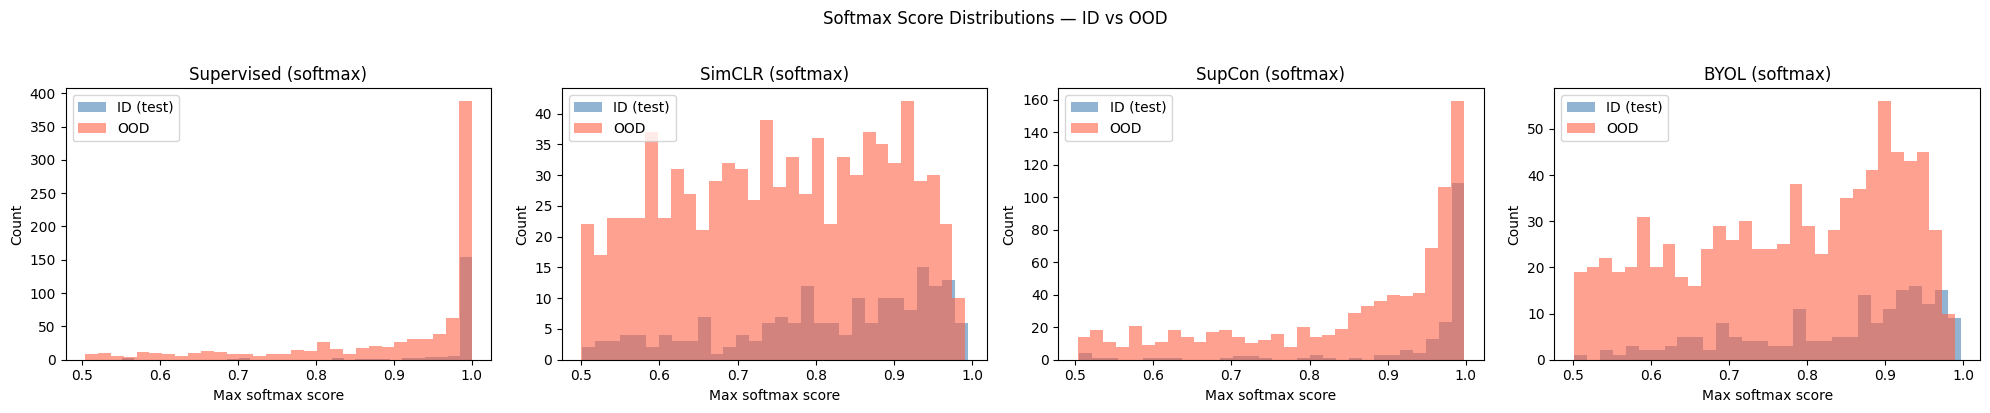

In [186]:
# Score distribution histograms — Softmax

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
pairs = [
    ("Supervised (softmax)",  sup_score_test,    sup_score_tood),
    ("SimCLR (softmax)",      simclr_score_test, simclr_score_tood),
    ("SupCon (softmax)",      supcon_score_test, supcon_score_tood),
    ("BYOL (softmax)",        byol_score_test,   byol_score_tood),
]
for ax, (title, id_scores, ood_scores) in zip(axes, pairs):
    ax.hist(id_scores,  bins=30, alpha=0.6, label="ID (test)", color="steelblue")
    ax.hist(ood_scores, bins=30, alpha=0.6, label="OOD",       color="tomato")
    ax.set_title(title)
    ax.set_xlabel("Max softmax score")
    ax.set_ylabel("Count")
    ax.legend()
plt.suptitle("Softmax Score Distributions — ID vs OOD", y=1.02)
plt.tight_layout()
plt.show()

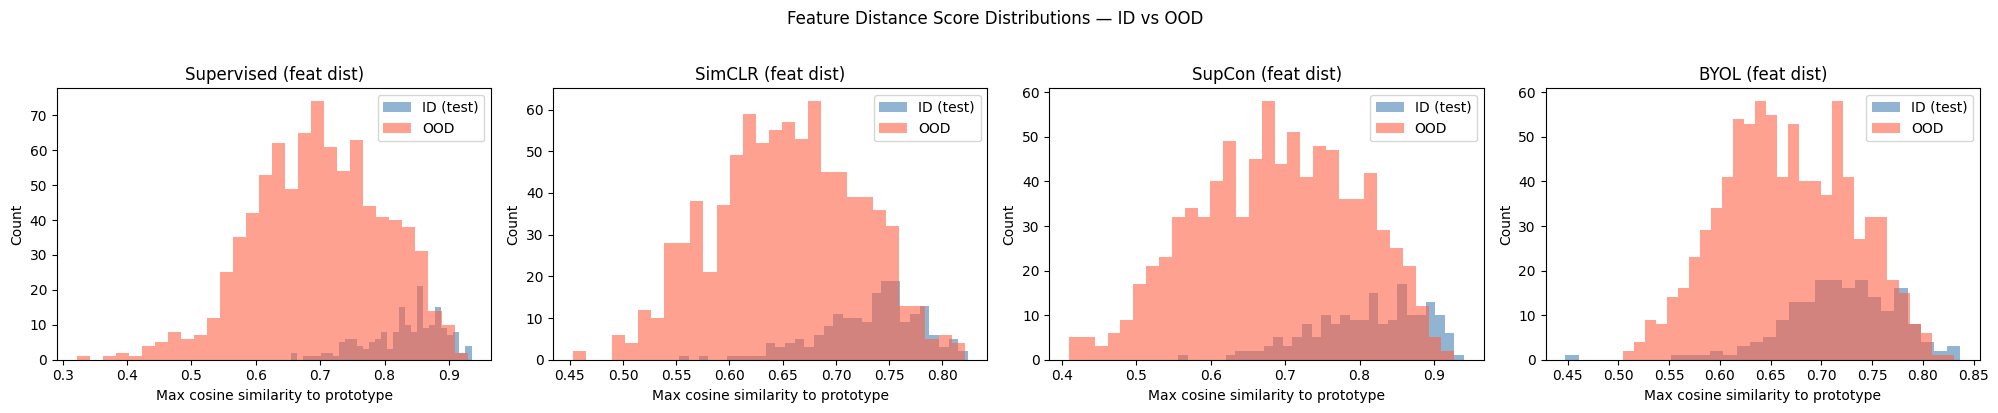

In [187]:
# Score distribution histograms — Feature distance (cosine)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
pairs = [
    ("Supervised (feat dist)",  sup_feat_test.numpy(),    sup_feat_tood.numpy()),
    ("SimCLR (feat dist)",      simclr_feat_test.numpy(), simclr_feat_tood.numpy()),
    ("SupCon (feat dist)",      supcon_feat_test.numpy(), supcon_feat_tood.numpy()),
    ("BYOL (feat dist)",        byol_feat_test.numpy(),   byol_feat_tood.numpy()),
]
for ax, (title, id_scores, ood_scores) in zip(axes, pairs):
    ax.hist(id_scores,  bins=30, alpha=0.6, label="ID (test)", color="steelblue")
    ax.hist(ood_scores, bins=30, alpha=0.6, label="OOD",       color="tomato")
    ax.set_title(title)
    ax.set_xlabel("Max cosine similarity to prototype")
    ax.set_ylabel("Count")
    ax.legend()
plt.suptitle("Feature Distance Score Distributions — ID vs OOD", y=1.02)
plt.tight_layout()
plt.show()

In [188]:
y_val_np = y_val.numpy()

thresh_df_sup    = tune_threshold(H_sup_val_l2,    y_val_np, H_sup_vood_l2,    proto_sup)
thresh_df_simclr = tune_threshold(H_simclr_val_l2, y_val_np, H_simclr_vood_l2, proto_simclr)
thresh_df_supcon = tune_threshold(H_supcon_val_l2, y_val_np, H_supcon_vood_l2, proto_supcon)
thresh_df_byol   = tune_threshold(H_byol_val_l2,   y_val_np, H_byol_vood_l2,   proto_byol)

print("Threshold tuning done.")

Threshold tuning done.


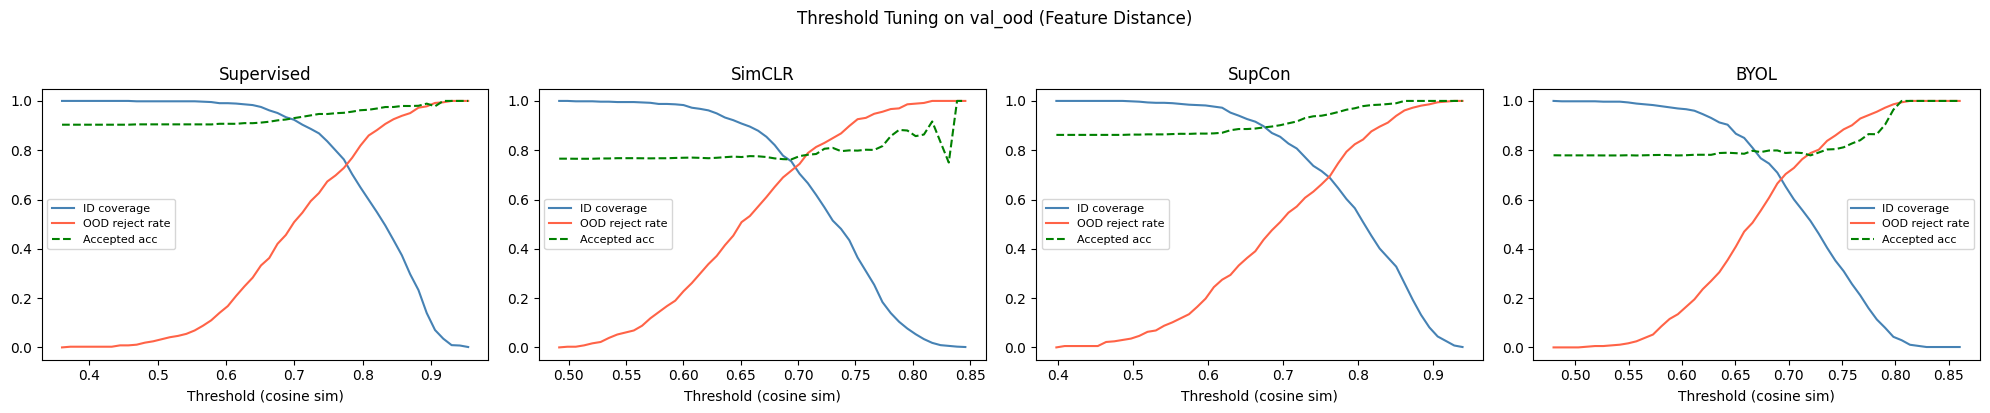

In [189]:
# Plot coverage vs OOD reject rate curves

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
data = [
    ("Supervised",  thresh_df_sup),
    ("SimCLR",      thresh_df_simclr),
    ("SupCon",      thresh_df_supcon),
    ("BYOL",        thresh_df_byol),
]
for ax, (name, df) in zip(axes, data):
    ax.plot(df["threshold"], df["id_coverage"],     label="ID coverage",     color="steelblue")
    ax.plot(df["threshold"], df["ood_reject_rate"], label="OOD reject rate", color="tomato")
    ax.plot(df["threshold"], df["id_accepted_acc"], label="Accepted acc",    color="green", linestyle="--")
    ax.set_title(name)
    ax.set_xlabel("Threshold (cosine sim)")
    ax.legend(fontsize=8)
plt.suptitle("Threshold Tuning on val_ood (Feature Distance)", y=1.02)
plt.tight_layout()
plt.show()

In [190]:
t_sup    = best_threshold(thresh_df_sup)
t_simclr = best_threshold(thresh_df_simclr)
t_supcon = best_threshold(thresh_df_supcon)
t_byol   = best_threshold(thresh_df_byol)

print(f"Selected thresholds — Supervised: {t_sup:.4f} | SimCLR: {t_simclr:.4f} | SupCon: {t_supcon:.4f} | BYOL: {t_byol:.4f}")

Selected thresholds — Supervised: 0.7482 | SimCLR: 0.6796 | SupCon: 0.7186 | BYOL: 0.6661


In [191]:
y_test_np = y_test.numpy()

res_sup    = eval_ood_final(H_sup_test_l2,    y_test_np, H_sup_tood_l2,    proto_sup,    t_sup,    "Supervised")
res_simclr = eval_ood_final(H_simclr_test_l2, y_test_np, H_simclr_tood_l2, proto_simclr, t_simclr, "SimCLR")
res_supcon = eval_ood_final(H_supcon_test_l2, y_test_np, H_supcon_tood_l2, proto_supcon, t_supcon, "SupCon")
res_byol   = eval_ood_final(H_byol_test_l2,   y_test_np, H_byol_tood_l2,   proto_byol,   t_byol,   "BYOL")


  Supervised

  Feature AUROC (ID vs OOD): 0.8734
  Threshold:                 0.7482
  ID coverage:               0.8846
  Accepted ID accuracy:      0.9752
  OOD reject rate:           0.6682

  SimCLR

  Feature AUROC (ID vs OOD): 0.8252
  Threshold:                 0.6796
  ID coverage:               0.8626
  Accepted ID accuracy:      0.8790
  OOD reject rate:           0.6424

  SupCon

  Feature AUROC (ID vs OOD): 0.8192
  Threshold:                 0.7186
  ID coverage:               0.8846
  Accepted ID accuracy:      0.9503
  OOD reject rate:           0.5906

  BYOL

  Feature AUROC (ID vs OOD): 0.7372
  Threshold:                 0.6661
  ID coverage:               0.8462
  Accepted ID accuracy:      0.8766
  OOD reject rate:           0.5141


---
## Section 5b — ViT-Base Supervised Baseline

- `google/vit-base-patch16-224` fine-tuned with cross-entropy
- All weights trainable, AdamW lr=2e-5, CosineAnnealingLR
- OOD score: cosine similarity to CLS token prototypes (768-dim)
- Same evaluation protocol as all other methods

In [148]:
# ViT config
from transformers import ViTForImageClassification

VIT_MODEL_NAME = 'google/vit-base-patch16-224'
VIT_LR         = 2e-5
VIT_EPOCHS     = 10
VIT_BATCH      = 32

print(f'ViT config: model={VIT_MODEL_NAME}, lr={VIT_LR}, epochs={VIT_EPOCHS}, batch={VIT_BATCH}')

/Users/kuoweitseng/anaconda3/envs/rustai_py312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ViT config: model=google/vit-base-patch16-224, lr=2e-05, epochs=10, batch=32


In [149]:
# ViT dataloaders — same transforms as other methods

train_dl_vit   = DataLoader(datasets.ImageFolder(TRAIN_DIR,    transform=train_tf),
                            batch_size=VIT_BATCH, shuffle=True,  num_workers=NUM_WORKERS)
val_dl_vit     = DataLoader(datasets.ImageFolder(VAL_DIR,      transform=eval_tf),
                            batch_size=VIT_BATCH, shuffle=False, num_workers=NUM_WORKERS)
train_dl_vit_eval = DataLoader(datasets.ImageFolder(TRAIN_DIR, transform=eval_tf),
                            batch_size=VIT_BATCH, shuffle=False, num_workers=NUM_WORKERS)

print('ViT dataloaders ready.')

ViT dataloaders ready.


In [150]:
# Load ViT with 2-class head

vit_model = ViTForImageClassification.from_pretrained(
    VIT_MODEL_NAME,
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True,
).to(DEVICE)

trainable = sum(p.numel() for p in vit_model.parameters() if p.requires_grad)
print(f'ViT trainable params: {trainable:,}')

Loading weights: 100%|██████████| 200/200 [00:00<00:00, 8857.43it/s]
ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([2, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([2])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


ViT trainable params: 85,800,194


In [151]:
# ViT training loop

def fit_vit(model, train_dl, val_dl, optimizer, scheduler, device, epochs, checkpoint_path):
    criterion    = nn.CrossEntropyLoss()
    best_val_acc = 0.0
    history      = []
    for epoch in range(1, epochs + 1):
        model.train()
        t_loss, t_correct, t_total = 0.0, 0, 0
        for images, labels in train_dl:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            out  = model(pixel_values=images)
            loss = criterion(out.logits, labels)
            loss.backward()
            optimizer.step()
            t_loss    += loss.item() * images.size(0)
            t_correct += (out.logits.argmax(1) == labels).sum().item()
            t_total   += images.size(0)
        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_dl:
                images, labels = images.to(device), labels.to(device)
                out  = model(pixel_values=images)
                loss = criterion(out.logits, labels)
                v_loss    += loss.item() * images.size(0)
                v_correct += (out.logits.argmax(1) == labels).sum().item()
                v_total   += images.size(0)
        tl = t_loss/t_total; ta = t_correct/t_total
        vl = v_loss/v_total; va = v_correct/v_total
        if scheduler: scheduler.step()
        if va > best_val_acc:
            best_val_acc = va
            torch.save(model.state_dict(), checkpoint_path)
        history.append({'epoch': epoch, 'train_loss': tl, 'train_acc': ta, 'val_loss': vl, 'val_acc': va})
        print(f'Epoch {epoch:02d}/{epochs} | train_loss={tl:.4f} acc={ta:.4f} | val_loss={vl:.4f} acc={va:.4f}')
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    print(f'\nBest ViT val acc: {best_val_acc:.4f}')
    return model, history, best_val_acc

In [152]:
# Train ViT

vit_optimizer = torch.optim.AdamW(vit_model.parameters(), lr=VIT_LR, weight_decay=1e-2)
vit_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(vit_optimizer, T_max=VIT_EPOCHS, eta_min=1e-6)

vit_model, vit_history, vit_best_val_acc = fit_vit(
    vit_model, train_dl_vit, val_dl_vit,
    vit_optimizer, vit_scheduler,
    DEVICE, epochs=VIT_EPOCHS, checkpoint_path='vit_best.pt'
)

Epoch 01/10 | train_loss=0.3081 acc=0.8680 | val_loss=0.2453 acc=0.8959
Epoch 02/10 | train_loss=0.0817 acc=0.9718 | val_loss=0.2105 acc=0.9096
Epoch 03/10 | train_loss=0.0316 acc=0.9913 | val_loss=0.1904 acc=0.9265
Epoch 04/10 | train_loss=0.0137 acc=0.9972 | val_loss=0.1867 acc=0.9311
Epoch 05/10 | train_loss=0.0075 acc=0.9992 | val_loss=0.1951 acc=0.9280
Epoch 06/10 | train_loss=0.0063 acc=0.9984 | val_loss=0.1979 acc=0.9280
Epoch 07/10 | train_loss=0.0030 acc=1.0000 | val_loss=0.2011 acc=0.9311
Epoch 08/10 | train_loss=0.0023 acc=1.0000 | val_loss=0.2059 acc=0.9280
Epoch 09/10 | train_loss=0.0020 acc=1.0000 | val_loss=0.2075 acc=0.9280
Epoch 10/10 | train_loss=0.0022 acc=1.0000 | val_loss=0.2060 acc=0.9311

Best ViT val acc: 0.9311


In [153]:
# ViT ID test accuracy

vit_model.eval()
vit_test_preds, vit_test_labels = [], []
with torch.no_grad():
    for images, labels in test_dl_eval:
        out = vit_model(pixel_values=images.to(DEVICE))
        vit_test_preds.extend(out.logits.argmax(1).cpu().numpy())
        vit_test_labels.extend(labels.numpy())

vit_test_acc = accuracy_score(vit_test_labels, vit_test_preds)
print(f'ViT test accuracy (ID): {vit_test_acc:.4f}')
print()
print(classification_report(vit_test_labels, vit_test_preds, target_names=CLASS_NAMES))

ViT test accuracy (ID): 0.9615

              precision    recall  f1-score   support

   CORROSION       0.98      0.95      0.96        99
 NOCORROSION       0.94      0.98      0.96        83

    accuracy                           0.96       182
   macro avg       0.96      0.96      0.96       182
weighted avg       0.96      0.96      0.96       182



In [154]:
# Extract ViT CLS token features from all splits

def extract_vit_features(model, dataloader, device):
    model.eval()
    all_h, all_labels = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            out = model.vit(pixel_values=images.to(device))
            cls = out.last_hidden_state[:, 0, :]  # [B, 768]
            all_h.append(cls.cpu())
            all_labels.append(labels.cpu())
    return torch.cat(all_h, dim=0), torch.cat(all_labels, dim=0)


H_vit_train, _ = extract_vit_features(vit_model, train_dl_vit_eval, DEVICE)
H_vit_val,   _ = extract_vit_features(vit_model, val_dl_eval,       DEVICE)
H_vit_test,  _ = extract_vit_features(vit_model, test_dl_eval,      DEVICE)
H_vit_vood,  _ = extract_vit_features(vit_model, val_ood_dl,        DEVICE)
H_vit_tood,  _ = extract_vit_features(vit_model, test_ood_dl,       DEVICE)

H_vit_train_l2 = l2_normalize_torch(H_vit_train)
H_vit_val_l2   = l2_normalize_torch(H_vit_val)
H_vit_test_l2  = l2_normalize_torch(H_vit_test)
H_vit_vood_l2  = l2_normalize_torch(H_vit_vood)
H_vit_tood_l2  = l2_normalize_torch(H_vit_tood)

print(f'ViT features extracted. CLS dim: {H_vit_train.shape[1]}')

ViT features extracted. CLS dim: 768


In [155]:
# ViT linear probe on CLS features

vit_probe_clf, vit_probe_train_acc, vit_probe_val_acc = run_linear_probe(
    H_vit_train_l2, y_train, H_vit_val_l2, y_val
)
vit_probe_test_acc = accuracy_score(y_test.numpy(), vit_probe_clf.predict(H_vit_test_l2.numpy()))
print(f'ViT linear probe — train={vit_probe_train_acc:.4f} | val={vit_probe_val_acc:.4f} | test={vit_probe_test_acc:.4f}')

ViT linear probe — train=0.9984 | val=0.9342 | test=0.9615


In [156]:
# ViT prototypes + cosine scores

proto_vit      = l2_normalize_torch(compute_class_prototypes(H_vit_train_l2, y_train, NUM_CLASSES))
vit_feat_test  = cosine_confidence_scores(H_vit_test_l2, proto_vit)
vit_feat_tood  = cosine_confidence_scores(H_vit_tood_l2, proto_vit)

print(f'ViT feature scores — ID mean={vit_feat_test.mean():.4f}, OOD mean={vit_feat_tood.mean():.4f}')
print(f'Score gap: {vit_feat_test.mean() - vit_feat_tood.mean():.4f}')

ViT feature scores — ID mean=0.5548, OOD mean=0.3430
Score gap: 0.2118


In [157]:
# ViT softmax scores

vit_softmax_test, vit_softmax_tood = [], []
with torch.no_grad():
    for images, _ in test_dl_eval:
        probs = F.softmax(vit_model(pixel_values=images.to(DEVICE)).logits, dim=1)
        vit_softmax_test.append(probs.cpu())
    for images, _ in test_ood_dl:
        probs = F.softmax(vit_model(pixel_values=images.to(DEVICE)).logits, dim=1)
        vit_softmax_tood.append(probs.cpu())

vit_softmax_test    = torch.cat(vit_softmax_test, dim=0)
vit_softmax_tood    = torch.cat(vit_softmax_tood, dim=0)
vit_score_test      = vit_softmax_test.max(dim=1).values.numpy()
vit_score_tood      = vit_softmax_tood.max(dim=1).values.numpy()
vit_corr_prob_tood  = vit_softmax_tood[:, CORROSION_IDX].numpy()
vit_ood_as_corr     = (vit_softmax_tood.argmax(dim=1).numpy() == CORROSION_IDX).mean()

print(f'ViT softmax — ID mean={vit_score_test.mean():.4f}, OOD mean={vit_score_tood.mean():.4f}')
print(f'% OOD as CORROSION: {vit_ood_as_corr*100:.1f}%')

ViT softmax — ID mean=0.9677, OOD mean=0.8560
% OOD as CORROSION: 55.5%


In [158]:
# ViT AUROC + threshold tuning

auroc_vit_softmax = compute_auroc(vit_score_test,          vit_score_tood)
auroc_vit_feat    = compute_auroc(vit_feat_test.numpy(),   vit_feat_tood.numpy())

thresh_df_vit = tune_threshold(H_vit_val_l2, y_val.numpy(), H_vit_vood_l2, proto_vit)
t_vit         = best_threshold(thresh_df_vit)

print(f'ViT Softmax AUROC: {auroc_vit_softmax:.4f}')
print(f'ViT Feature AUROC: {auroc_vit_feat:.4f}')
print(f'Selected threshold: {t_vit:.4f}')

res_vit = eval_ood_final(H_vit_test_l2, y_test.numpy(), H_vit_tood_l2, proto_vit, t_vit, 'ViT')

ViT Softmax AUROC: 0.8126
ViT Feature AUROC: 0.8005
Selected threshold: 0.3194

  ViT

  Feature AUROC (ID vs OOD): 0.8005
  Threshold:                 0.3194
  ID coverage:               0.8571
  Accepted ID accuracy:      0.9744
  OOD reject rate:           0.5318


## Section 6 — Final Comparison

Summarize all metrics across the three methods.

In [192]:
# Build final summary table — all 5 methods

final_df = pd.DataFrame([
    {
        'Method':              'Supervised',
        'ID Test Acc':         sup_test_acc,
        'Softmax AUROC':       auroc_sup_softmax,
        'Feature AUROC':       auroc_sup_feat,
        'OOD Reject Rate':     res_sup['ood_reject_rate'],
        '% OOD as Corrosion':  sup_ood_as_corr,
        'Mean P(corr) on OOD': sup_corr_prob_tood.mean(),
    },
    {
        'Method':              'SimCLR',
        'ID Test Acc':         simclr_test_acc,
        'Softmax AUROC':       auroc_simclr_softmax,
        'Feature AUROC':       auroc_simclr_feat,
        'OOD Reject Rate':     res_simclr['ood_reject_rate'],
        '% OOD as Corrosion':  simclr_ood_as_corr,
        'Mean P(corr) on OOD': simclr_corr_prob_tood.mean(),
    },
    {
        'Method':              'SupCon',
        'ID Test Acc':         supcon_test_acc,
        'Softmax AUROC':       auroc_supcon_softmax,
        'Feature AUROC':       auroc_supcon_feat,
        'OOD Reject Rate':     res_supcon['ood_reject_rate'],
        '% OOD as Corrosion':  supcon_ood_as_corr,
        'Mean P(corr) on OOD': supcon_corr_prob_tood.mean(),
    },
    {
        'Method':              'BYOL',
        'ID Test Acc':         byol_test_acc,
        'Softmax AUROC':       auroc_byol_softmax,
        'Feature AUROC':       auroc_byol_feat,
        'OOD Reject Rate':     res_byol['ood_reject_rate'],
        '% OOD as Corrosion':  byol_ood_as_corr,
        'Mean P(corr) on OOD': byol_corr_prob_tood.mean(),
    },
    {
        'Method':              'ViT-Base',
        'ID Test Acc':         vit_test_acc,
        'Softmax AUROC':       auroc_vit_softmax,
        'Feature AUROC':       auroc_vit_feat,
        'OOD Reject Rate':     res_vit['ood_reject_rate'],
        '% OOD as Corrosion':  vit_ood_as_corr,
        'Mean P(corr) on OOD': vit_corr_prob_tood.mean(),
    },
])

final_df = final_df.set_index('Method')
print(final_df.to_string(float_format='{:.4f}'.format))

            ID Test Acc  Softmax AUROC  Feature AUROC  OOD Reject Rate  % OOD as Corrosion  Mean P(corr) on OOD
Method                                                                                                         
Supervised       0.9560         0.8022         0.8734           0.6682              0.5612               0.5709
SimCLR           0.9231         0.6296         0.8252           0.6424              0.5329               0.5144
SupCon           0.9176         0.7749         0.8192           0.5906              0.6929               0.6554
BYOL             0.9341         0.6409         0.7372           0.5141              0.5976               0.5761
ViT-Base         0.9615         0.8126         0.8005           0.5318              0.5553               0.5700


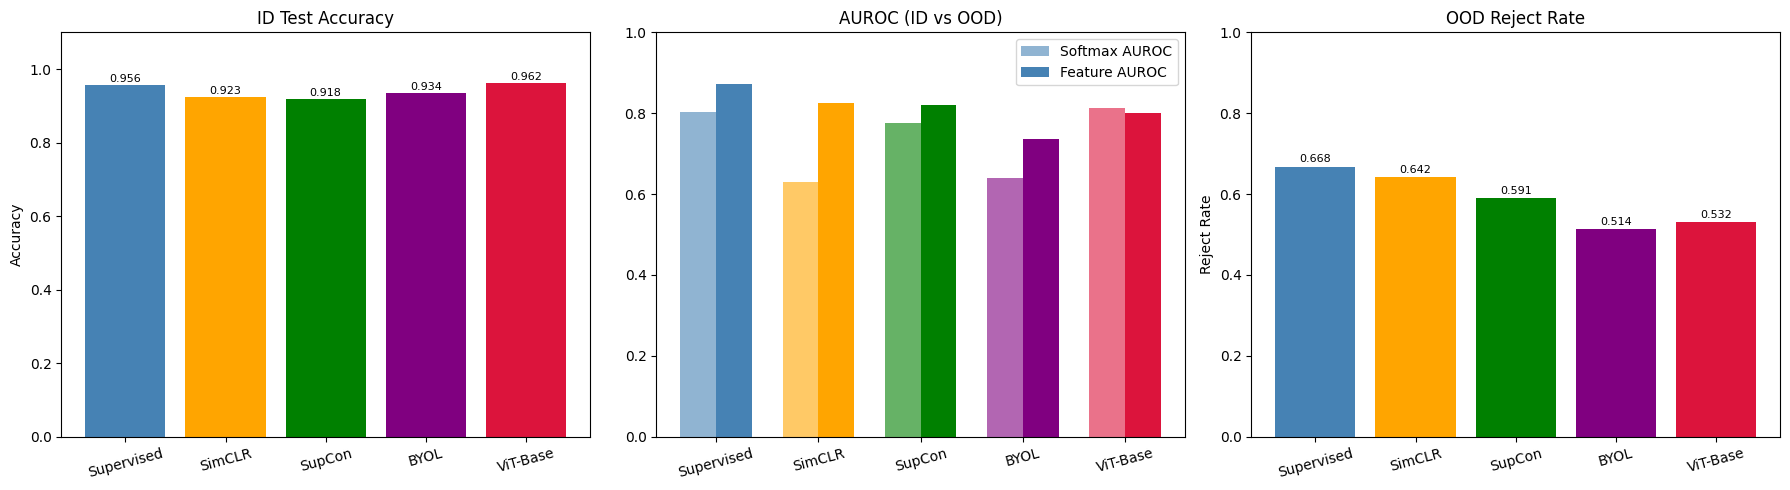

In [193]:
# Bar chart — ID accuracy, AUROC, OOD reject rate

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
methods = final_df.index.tolist()
colors  = ['steelblue', 'orange', 'green', 'purple', 'crimson']

axes[0].bar(methods, final_df['ID Test Acc'], color=colors)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('ID Test Accuracy')
axes[0].set_ylim(0, 1.1)
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(final_df['ID Test Acc']):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=8)

x = range(len(methods))
w = 0.35
axes[1].bar([i - w/2 for i in x], final_df['Softmax AUROC'], w, color=colors, alpha=0.6, label='Softmax AUROC')
axes[1].bar([i + w/2 for i in x], final_df['Feature AUROC'],  w, color=colors, alpha=1.0, label='Feature AUROC')
axes[1].set_title('AUROC (ID vs OOD)')
axes[1].set_ylim(0, 1.0)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(methods, rotation=15)
axes[1].legend()

axes[2].bar(methods, final_df['OOD Reject Rate'], color=colors)
axes[2].set_ylabel('Reject Rate')
axes[2].set_title('OOD Reject Rate')
axes[2].set_ylim(0, 1.0)
axes[2].tick_params(axis='x', rotation=15)
for i, v in enumerate(final_df['OOD Reject Rate']):
    axes[2].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

In [194]:
# Score gap analysis — all 5 methods

print('Score gap analysis (Feature cosine similarity):')
print(f"  {'Method':<15} {'ID mean':>10} {'OOD mean':>10} {'Gap':>10}")
print('-' * 50)
for name, id_s, ood_s in [
    ('Supervised', sup_feat_test.numpy(),    sup_feat_tood.numpy()),
    ('SimCLR',     simclr_feat_test.numpy(), simclr_feat_tood.numpy()),
    ('SupCon',     supcon_feat_test.numpy(), supcon_feat_tood.numpy()),
    ('BYOL',       byol_feat_test.numpy(),   byol_feat_tood.numpy()),
    ('ViT-Base',   vit_feat_test.numpy(),    vit_feat_tood.numpy()),
]:
    id_m, ood_m = id_s.mean(), ood_s.mean()
    print(f"  {name:<15} {id_m:>10.4f} {ood_m:>10.4f} {id_m-ood_m:>+10.4f}")

Score gap analysis (Feature cosine similarity):
  Method             ID mean   OOD mean        Gap
--------------------------------------------------
  Supervised          0.8326     0.6984    +0.1342
  SimCLR              0.7314     0.6534    +0.0780
  SupCon              0.8104     0.6888    +0.1216
  BYOL                0.7185     0.6661    +0.0524
  ViT-Base            0.5548     0.3430    +0.2118


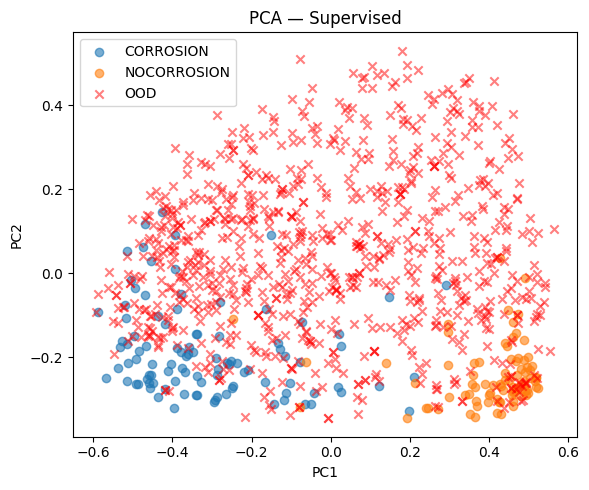

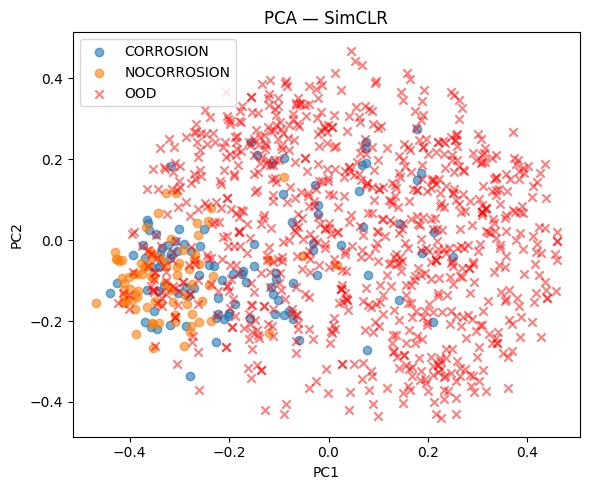

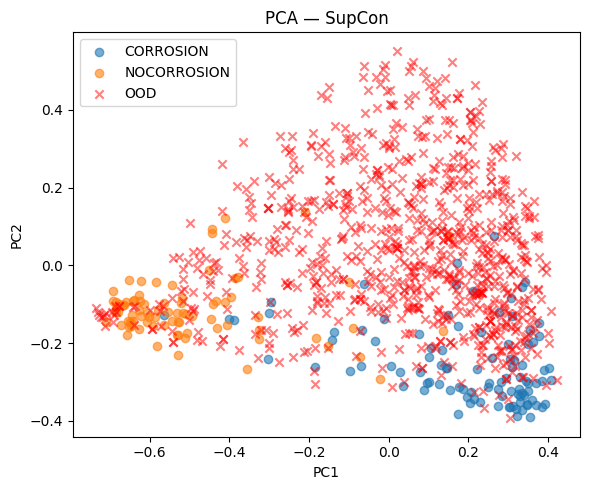

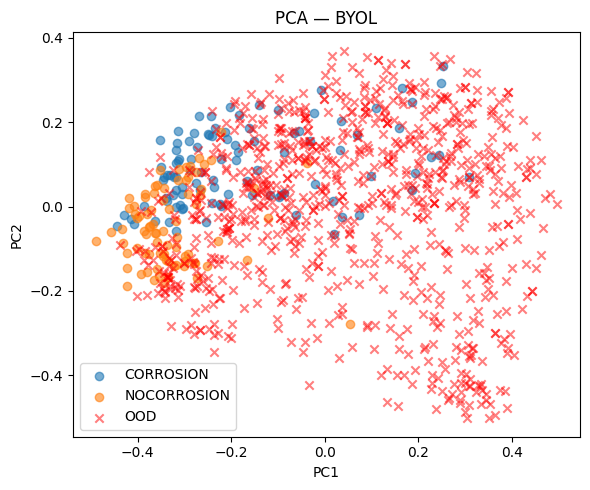

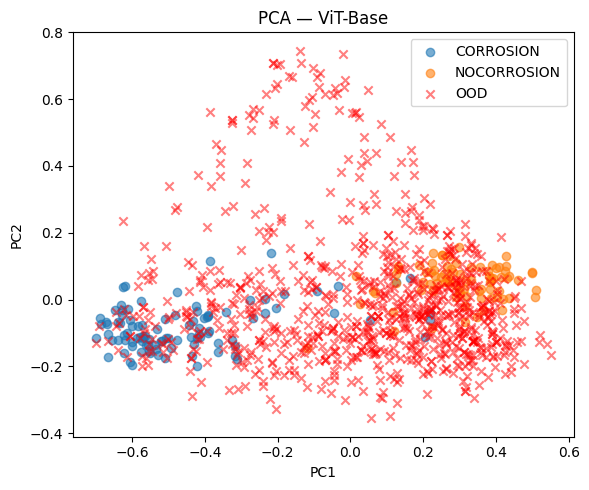

In [195]:
from sklearn.decomposition import PCA

visualize_feature_space(H_sup_test_l2,    y_test_np, H_sup_tood_l2,    CLASS_NAMES, 'PCA — Supervised')
visualize_feature_space(H_simclr_test_l2, y_test_np, H_simclr_tood_l2, CLASS_NAMES, 'PCA — SimCLR')
visualize_feature_space(H_supcon_test_l2, y_test_np, H_supcon_tood_l2, CLASS_NAMES, 'PCA — SupCon')
visualize_feature_space(H_byol_test_l2,   y_test_np, H_byol_tood_l2,   CLASS_NAMES, 'PCA — BYOL')
visualize_feature_space(H_vit_test_l2,    y_test_np, H_vit_tood_l2,    CLASS_NAMES, 'PCA — ViT-Base')

In [196]:
# Save final results

final_df.reset_index().to_csv('comparison_all_methods.csv', index=False)
print('Results saved to comparison_all_methods.csv')

torch.save({
    'sup_history':    sup_history,
    'simclr_history': simclr_history,
    'supcon_history': supcon_history,
    'byol_history':   byol_history,
    'vit_history':    vit_history,
    'final_results':  final_df.to_dict(),
    'thresholds':     {'sup': t_sup, 'simclr': t_simclr, 'supcon': t_supcon, 'byol': t_byol, 'vit': t_vit},
}, 'comparison_summary.pt')
print('Checkpoint saved to comparison_summary.pt')

Results saved to comparison_all_methods.csv
Checkpoint saved to comparison_summary.pt


## Final Interpretation

### Summary

- **Supervised (ResNet18)**: 
- **SimCLR**: 
- **SupCon**: 
- **BYOL**: 
- **ViT-Base**: 
